In [ ]:
# LIBRARIES INSTALLATION (if required)
!python -m pip install --upgrade pip
!pip install numpy torch scipy matplotlib torchsummary

[[0.225 0.164 0.165 0.124 0.241 0.104]
 [0.225 0.164 0.165 0.124 0.241 0.104]
 [0.225 0.164 0.165 0.124 0.241 0.104]
 [0.225 0.164 0.165 0.124 0.241 0.104]
 [0.138 0.22  0.125 0.204 0.328 0.188]
 [0.138 0.22  0.125 0.204 0.328 0.188]
 [0.138 0.22  0.125 0.204 0.328 0.188]
 [0.138 0.22  0.125 0.204 0.328 0.188]
 [0.129 0.278 0.125 0.201 0.266 0.135]
 [0.129 0.278 0.125 0.201 0.266 0.135]
 [0.129 0.278 0.125 0.201 0.266 0.135]
 [0.129 0.278 0.125 0.201 0.266 0.135]
 [0.308 0.131 0.247 0.116 0.224 0.332]
 [0.308 0.131 0.247 0.116 0.224 0.332]
 [0.308 0.131 0.247 0.116 0.224 0.332]
 [0.308 0.131 0.247 0.116 0.224 0.332]
 [0.302 0.15  0.186 0.234 0.345 0.226]
 [0.302 0.15  0.186 0.234 0.345 0.226]
 [0.302 0.15  0.186 0.234 0.345 0.226]
 [0.302 0.15  0.186 0.234 0.345 0.226]
 [0.302 0.15  0.186 0.234 0.345 0.226]]
[[337.282 314.413 731.816 631.356 519.79  721.677]
 [337.282 314.413 731.816 631.356 519.79  721.677]
 [337.282 314.413 731.816 631.356 519.79  721.677]
 [337.282 314.413 731.816 6

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\2496757954.py:600: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


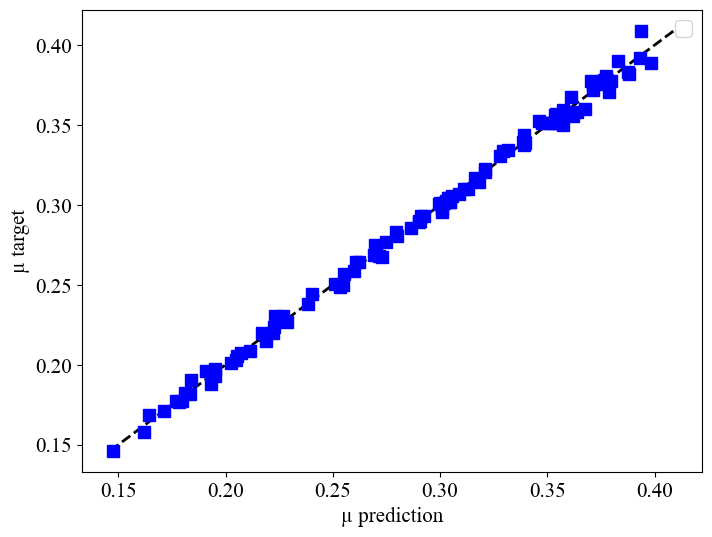

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\2496757954.py:611: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


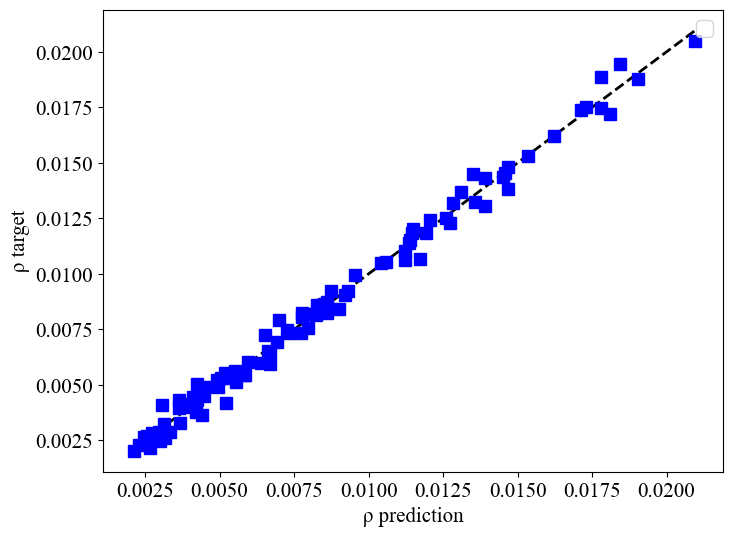

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]              32
         LeakyReLU-2                    [-1, 8]               0
            Linear-3                    [-1, 8]              72
         LeakyReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
Total params: 113
Trainable params: 113
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
net.0.weight: torch.Size([8, 3])
tensor([[-0.5281,  0.0598, -0.4478],
        [ 0.5714,  0.3647, -0.0532],
        [ 0.4163,  0.0564, -0.4836],
        [ 0.0290,  0.0041, -0.0736],
        [ 0.3088, -0.1301, -0.2038],
        [-0.2385,  0.025

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\2496757954.py:627: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("NN1_Model_weights.pth"))

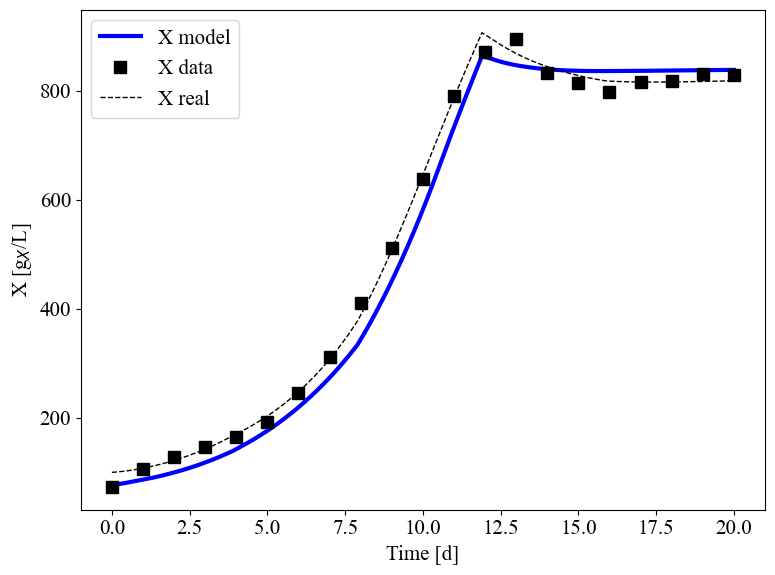

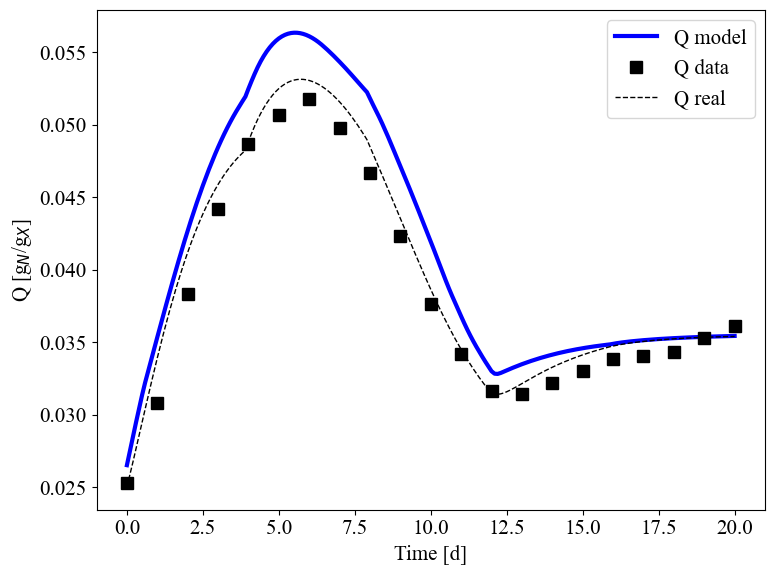

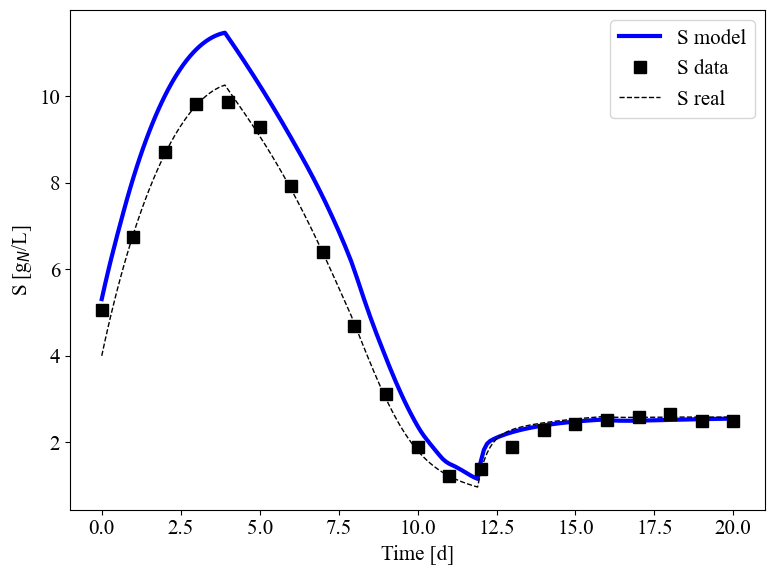

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\2496757954.py:750: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


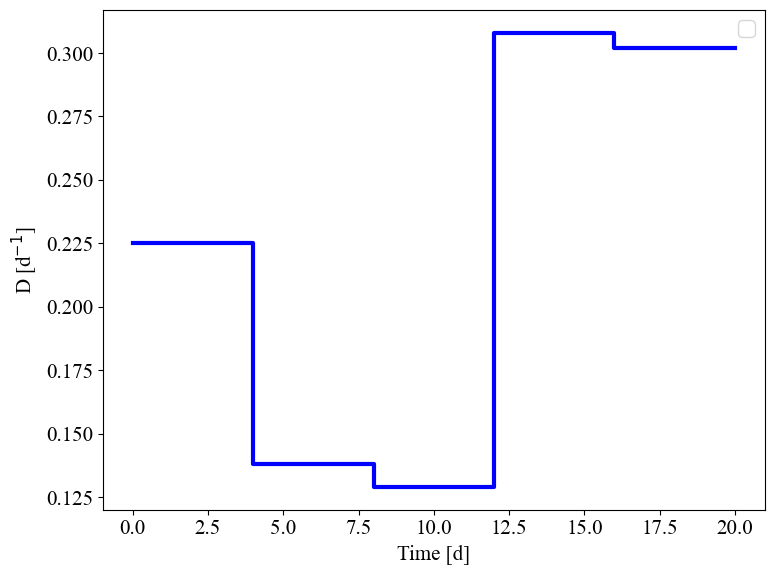

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\2496757954.py:760: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


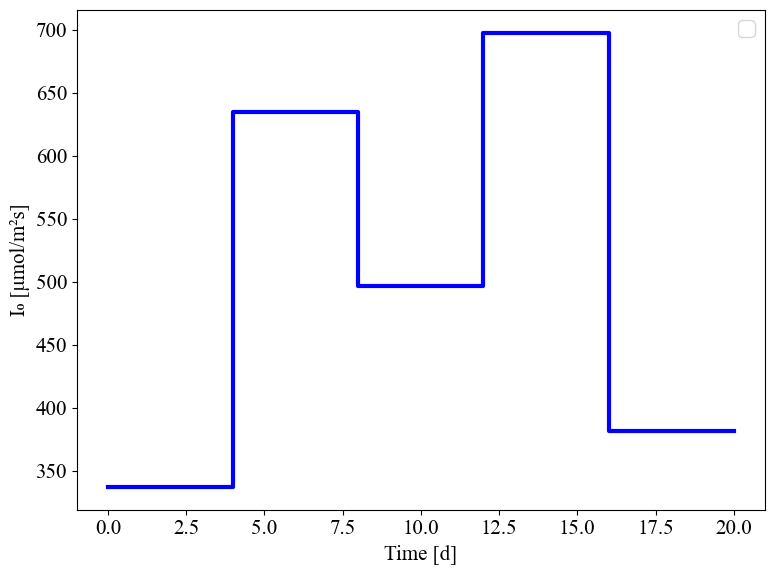

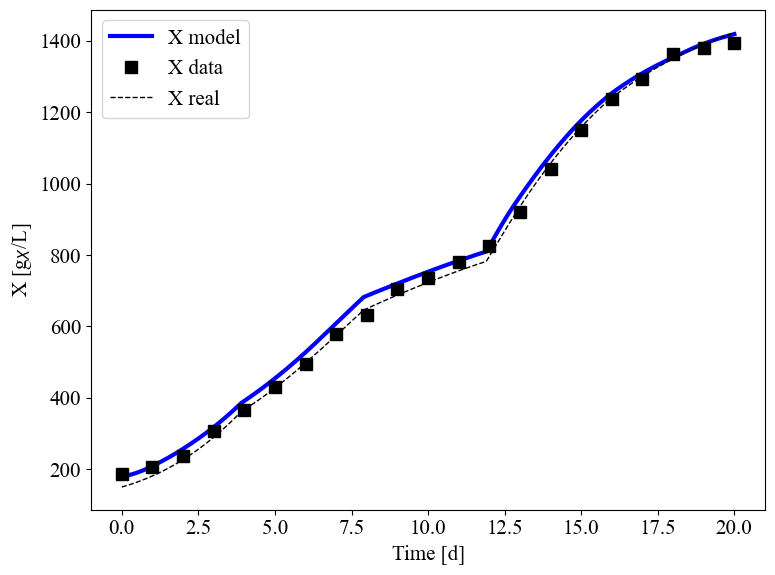

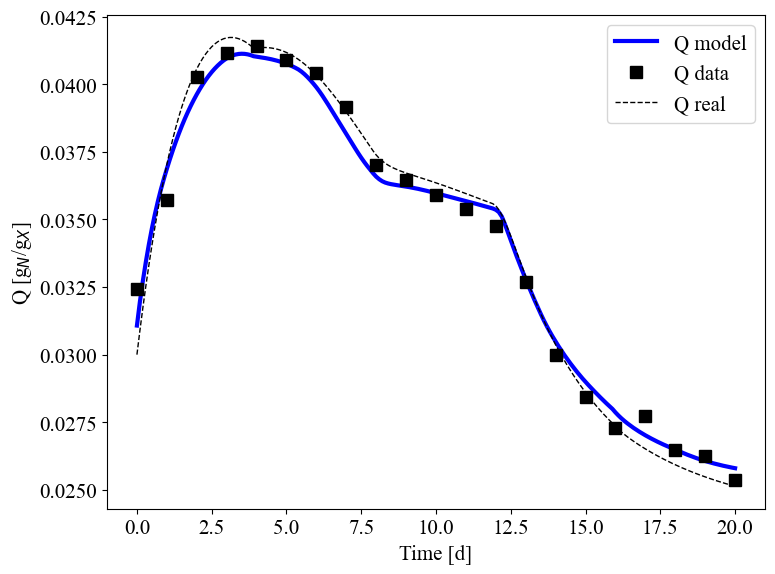

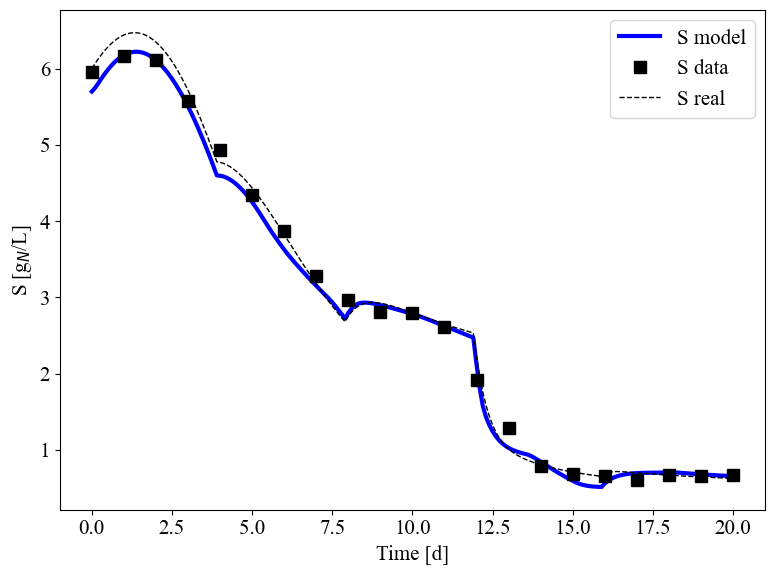

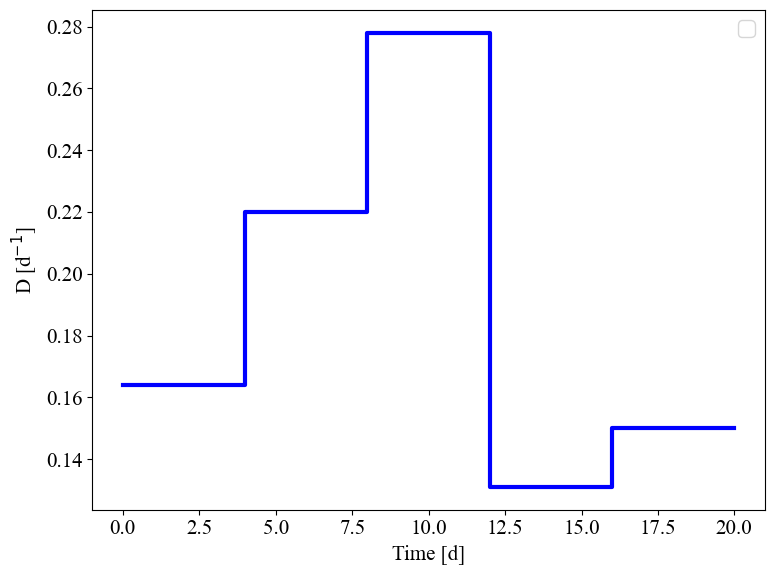

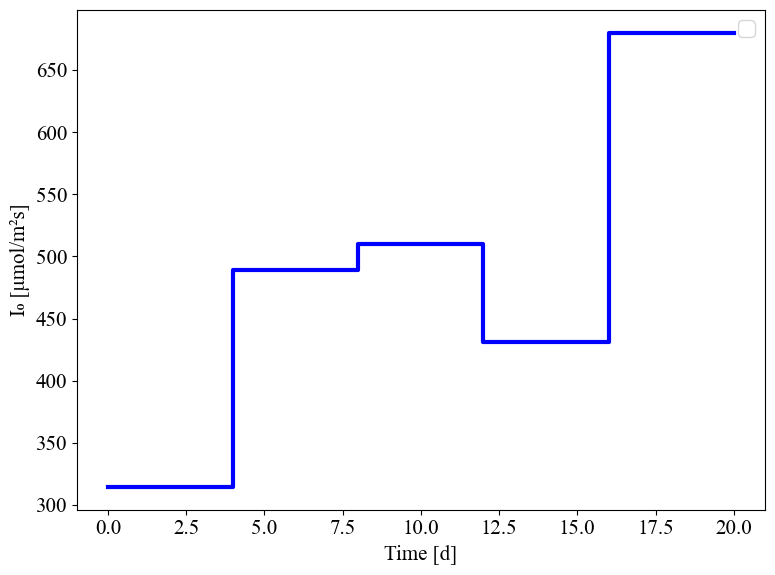

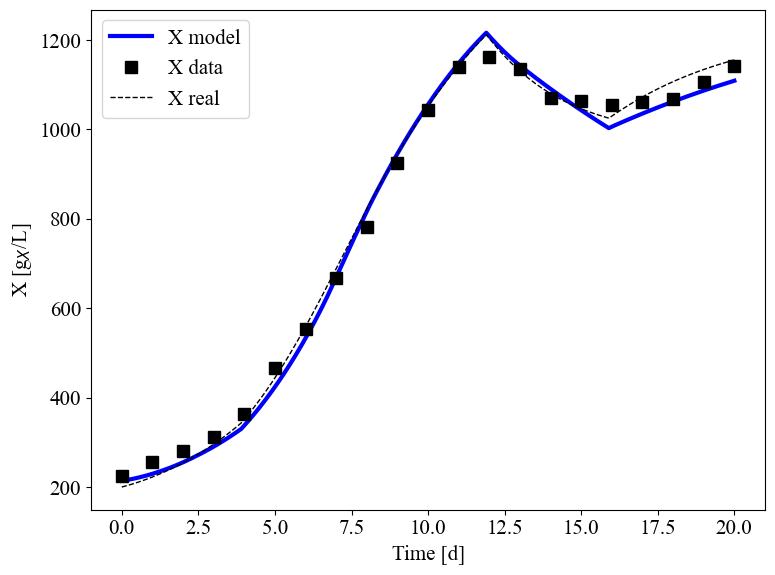

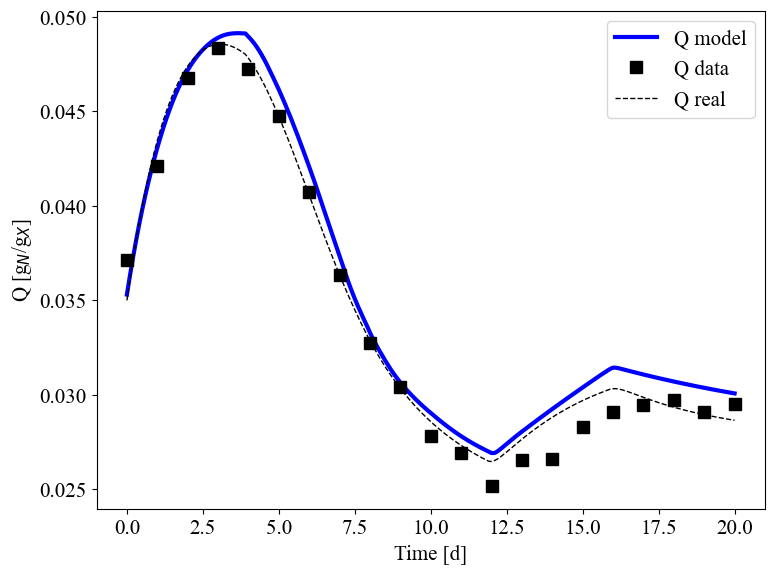

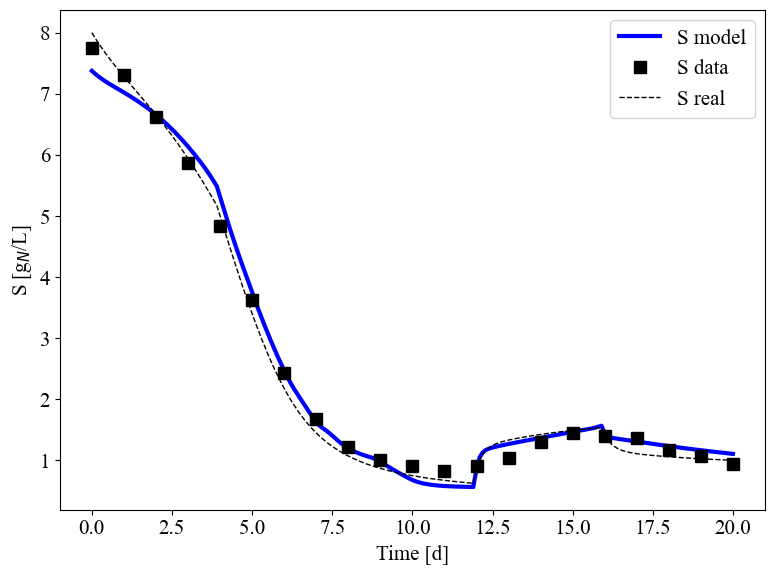

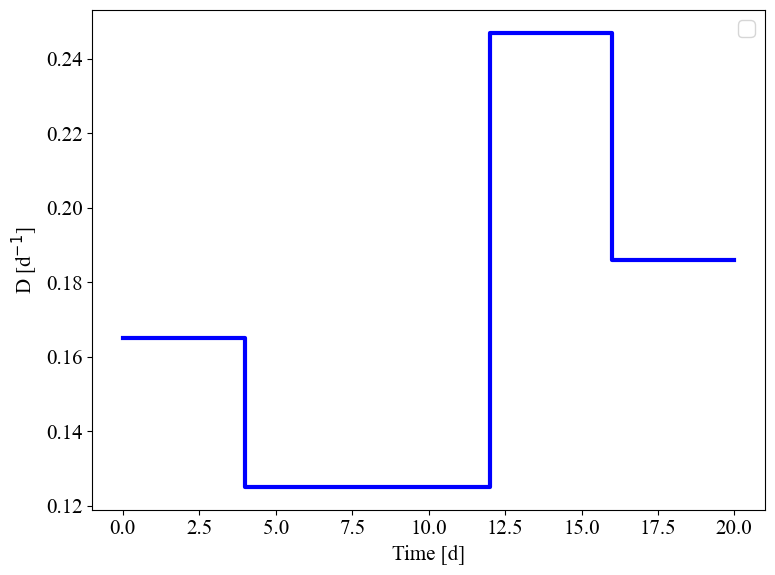

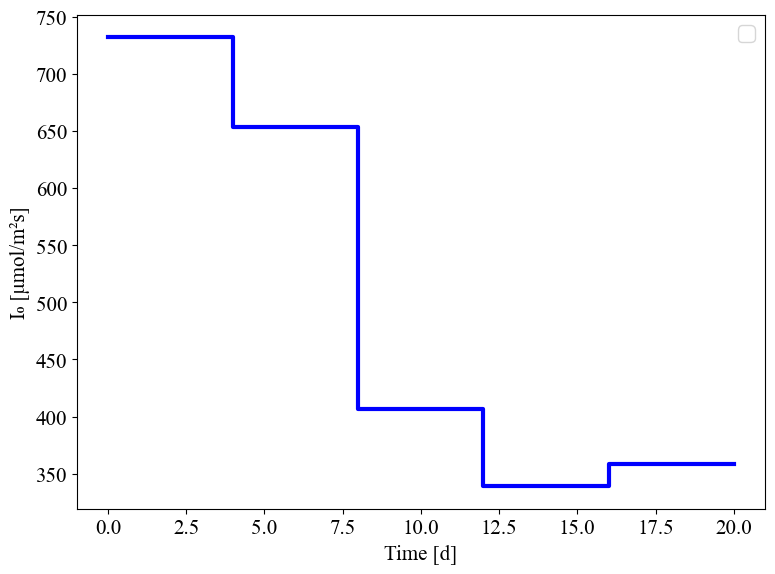

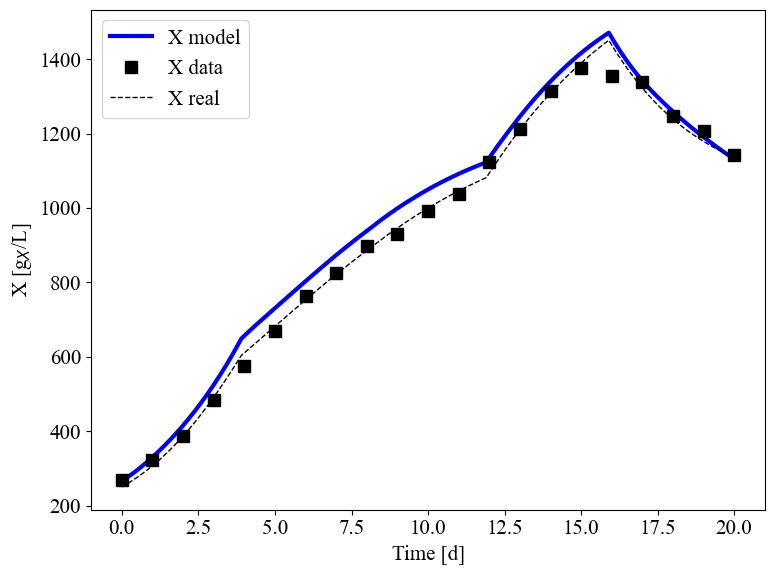

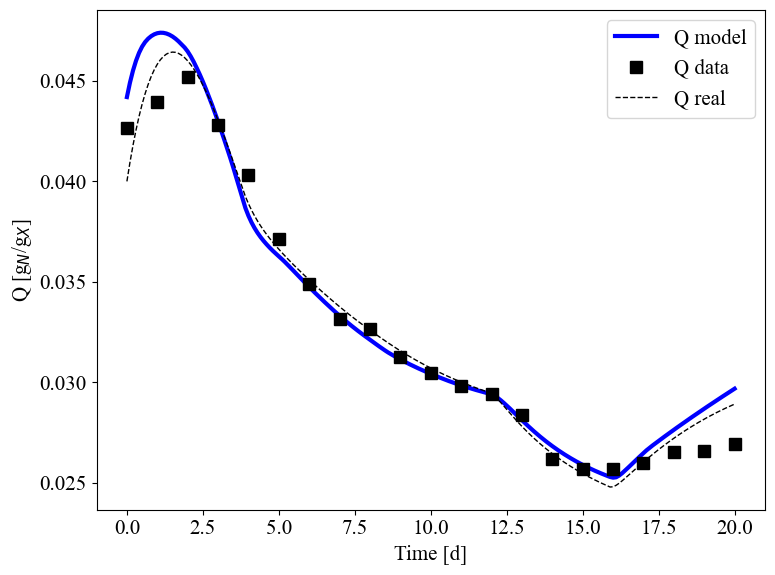

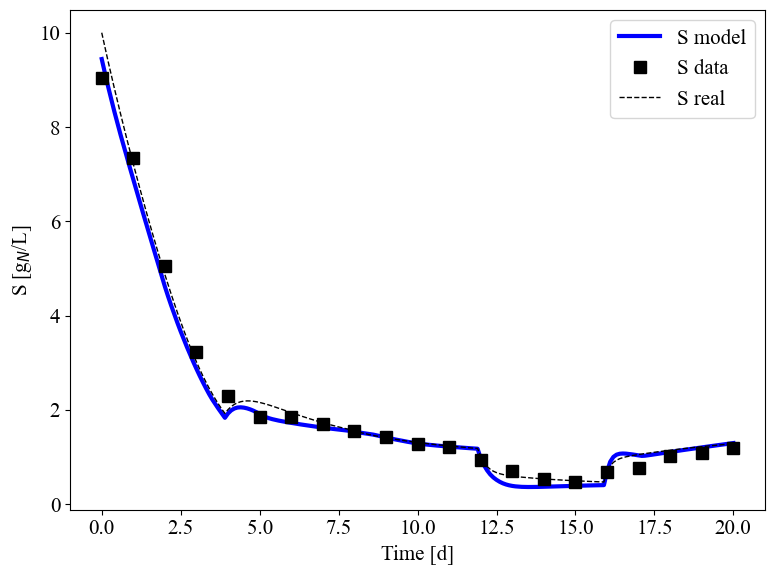

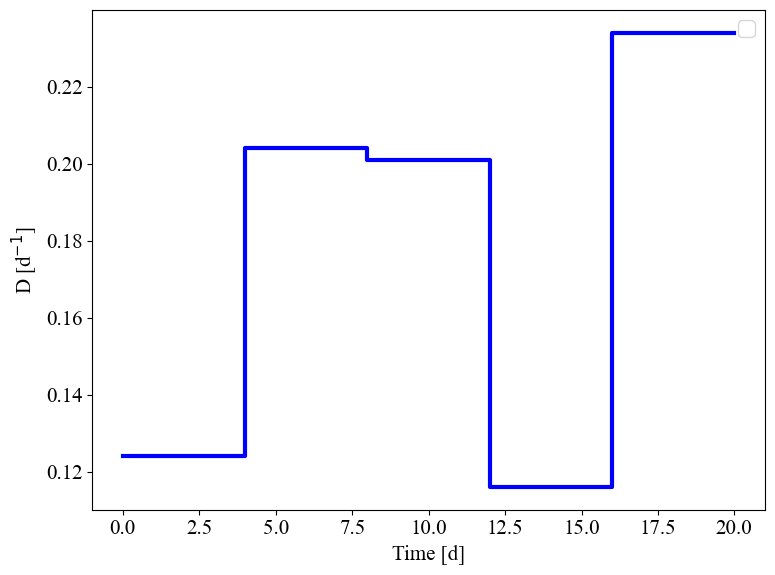

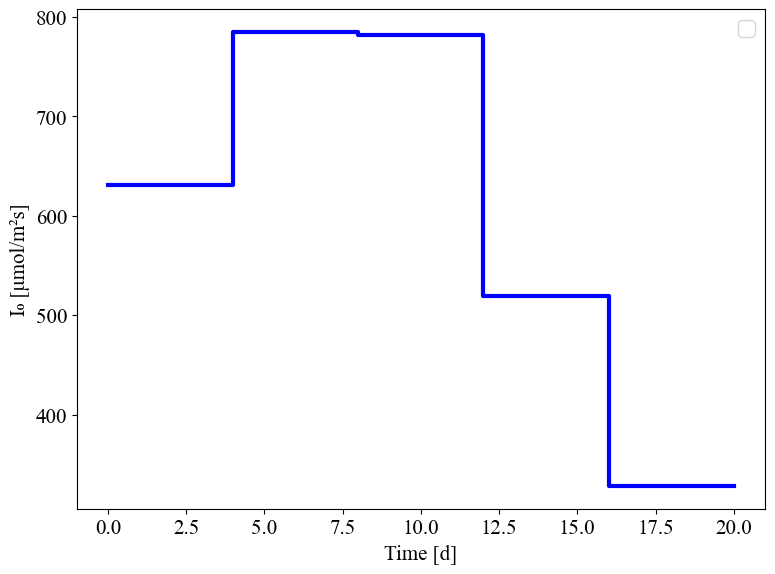

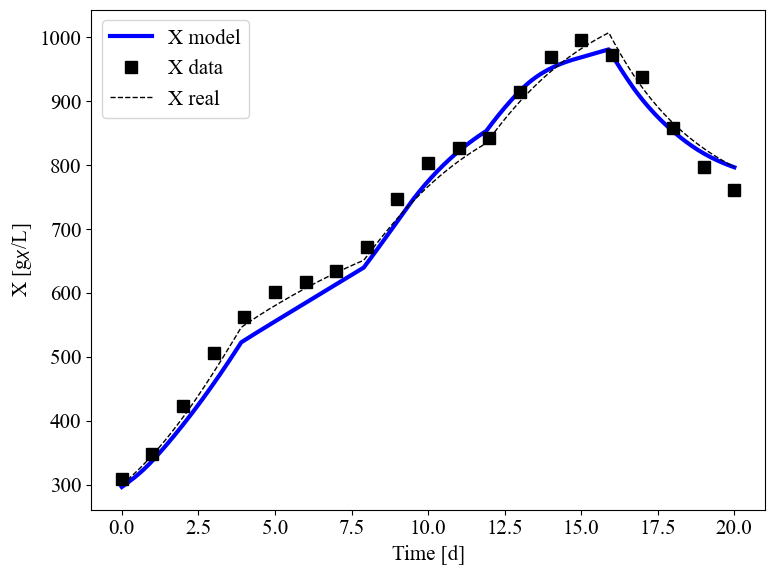

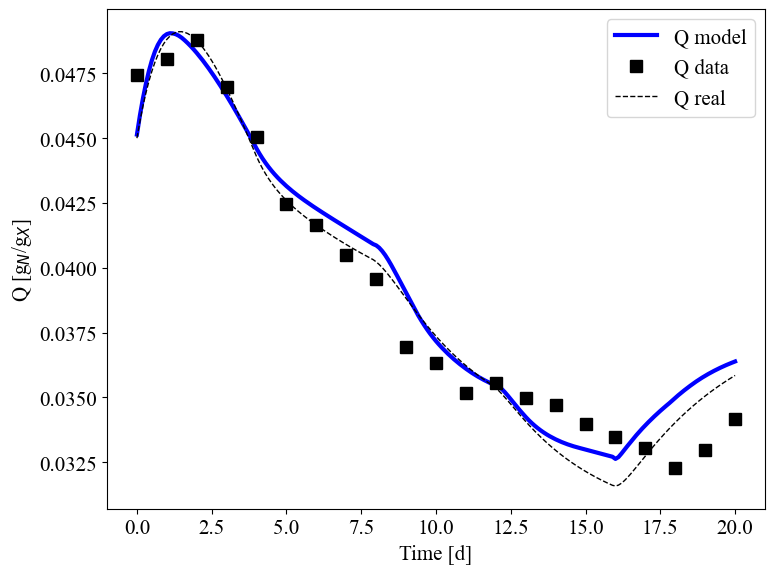

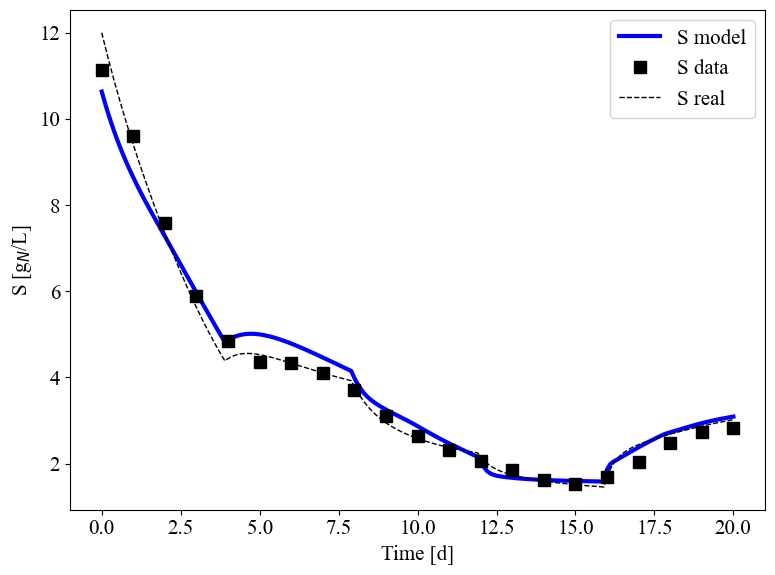

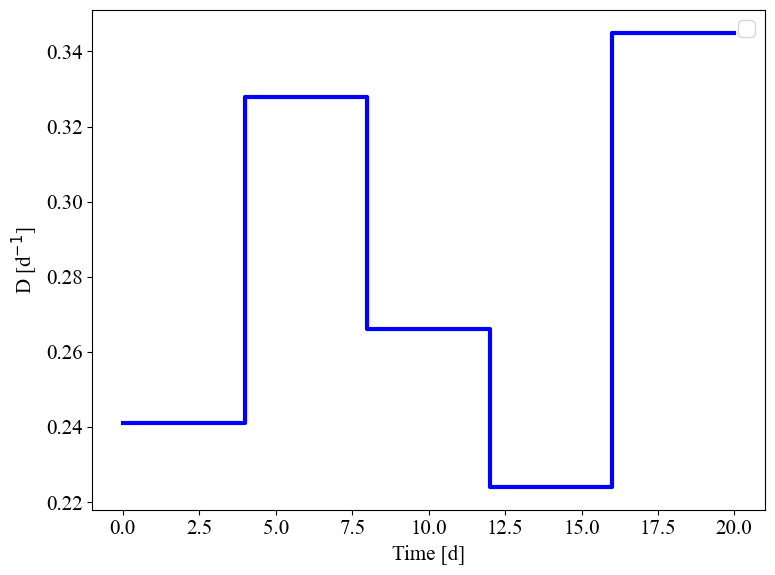

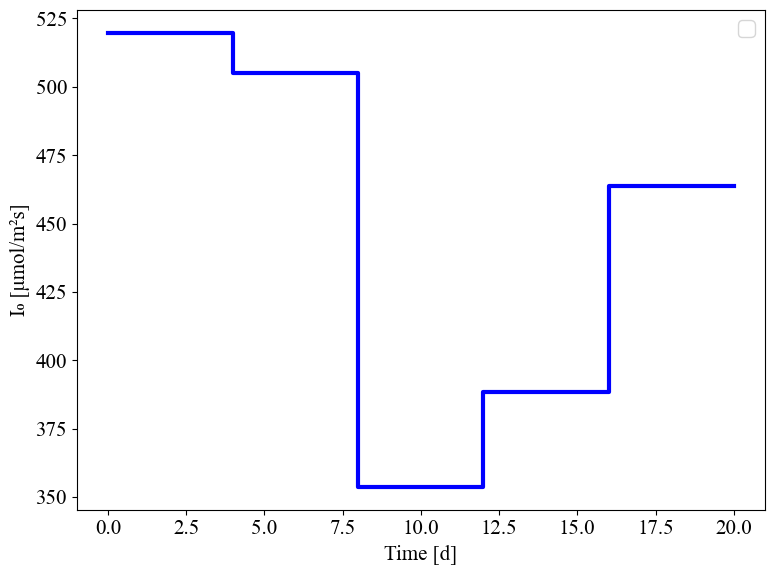

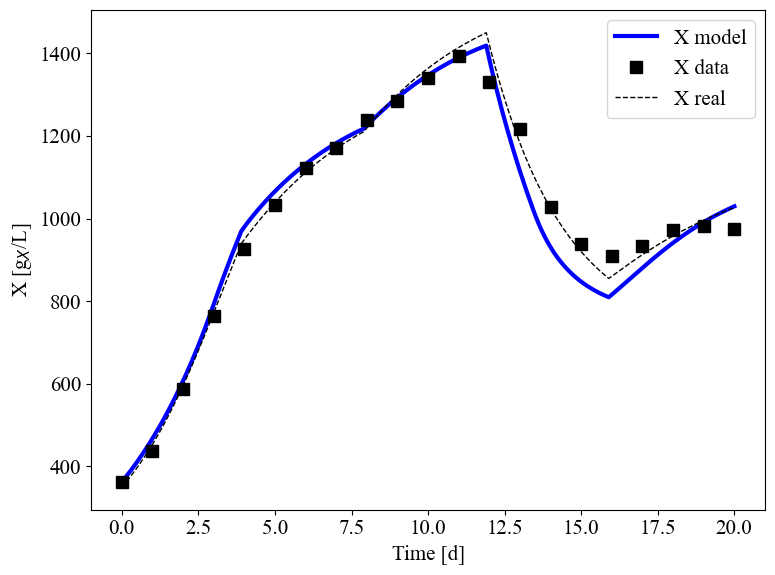

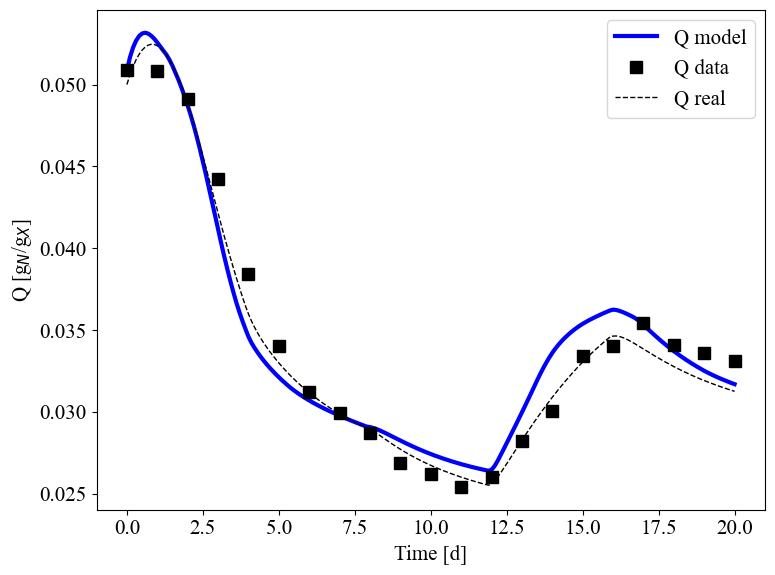

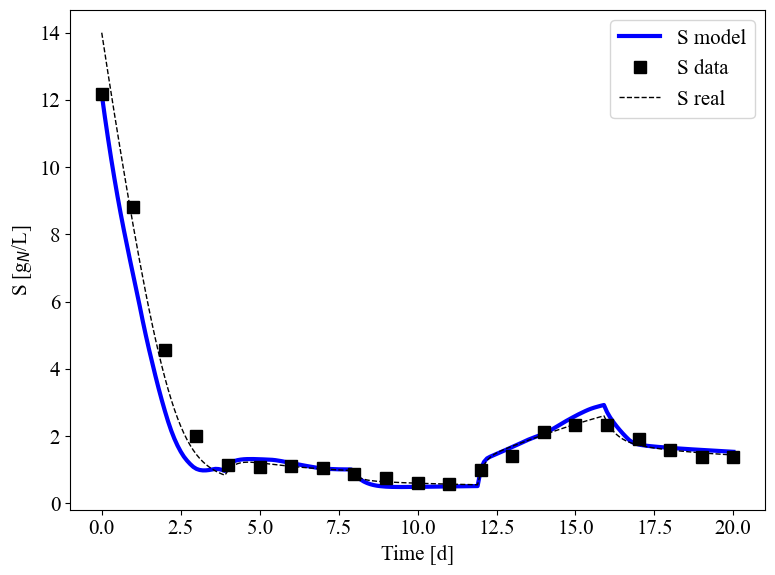

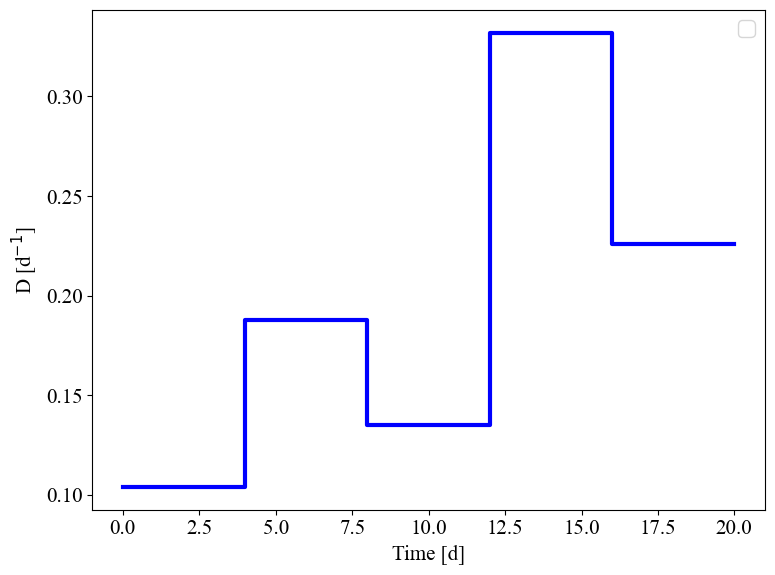

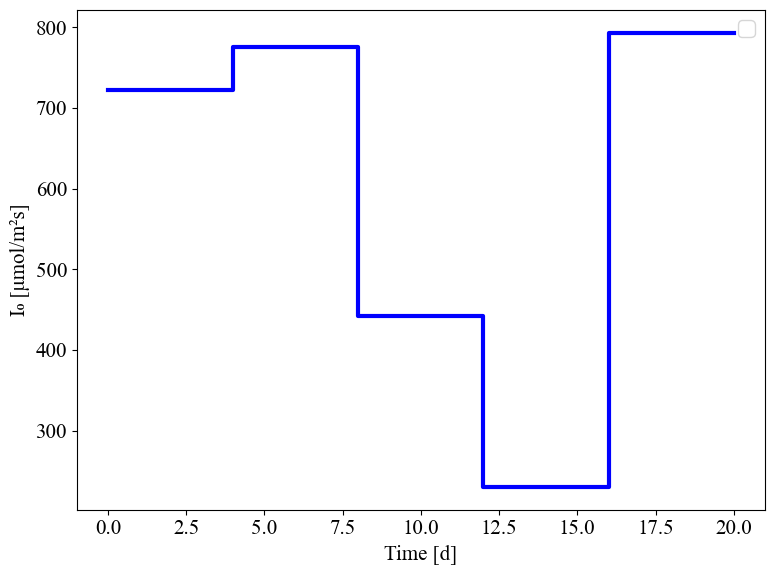


Relative Errors (Hybrid Model vs Measured Data):
Batch   Rel Error X   Rel Error Q   Rel Error S
    1        0.0830        0.0719        0.1270
    2        0.0347        0.0144        0.0601
    3        0.0384        0.0405        0.0783
    4        0.0457        0.0263        0.1071
    5        0.0369        0.0318        0.0727
    6        0.0403        0.0413        0.1391

Relative Errors (Hybrid Model vs Noise-Free System Data):
Batch   Rel Error X   Rel Error Q   Rel Error S
    1        0.0915        0.0444        0.1535
    2        0.0526        0.0131        0.0481
    3        0.0225        0.0235        0.0982
    4        0.0420        0.0173        0.1014
    5        0.0242        0.0145        0.0758
    6        0.0298        0.0300        0.1558

Standard deviations of the derivatives:
Standard deviation of dX/dt: 61.3277
Standard deviation of dQ/dt: 0.0030
Standard deviation of dS/dt: 1.2574


In [ ]:
# NN-BASED HYBRID MODEL 2025/03/05 03:20 PM (every 4 days)
# (Process noise is added separately from measurement noise)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import os

# Create directory for plots
os.makedirs('plots', exist_ok=True)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 15

# -------------------------------
# Utility: Rolling Average Smoothing
# -------------------------------
def rolling_average(signal, window_size):
    pad_width = window_size // 2
    padded_signal = np.pad(signal, pad_width, mode='edge')
    kernel = np.ones(window_size) / window_size
    return np.convolve(padded_signal, kernel, mode='valid')

# -------------------------------
# Configuration & Parameters
# -------------------------------
params = {
    'mu_tilde': 1.4846,
    'K_s': 10.954,
    'Q_0': 0.0089134,
    'Q_l': 0.13772,
    'rho_max': 0.058408,
    'R': 0.00723,  #0.00723,
    'K_sI_asterisk': 1.7983,
    'K_iI': 122.44,
    'gamma_max': 0.93005,
    'K_I_asterisk': 282.88,
    'a': 0.67014,
    'K_g': 10.67
}
S_in_base = 25  # Inlet substrate concentration

# Process noise level & corresponding sigma values
process_noise_level = 0.05
sigma_X = process_noise_level * 50    # For X
sigma_Q = process_noise_level * 0.0025  # For Q
sigma_S = process_noise_level * 1.30    # For S
# Standard deviations of the derivatives:
# Standard deviation of dX/dt: 43.1643
# Standard deviation of dQ/dt: 0.0032
# Standard deviation of dS/dt: 1.4370

total_batches = 6
t_max = 20      # days
n_steps = 21    # measurement points: t = 0,...,20
n_intervals = n_steps - 1  # 20 simulation intervals
t_eval = np.linspace(0, t_max, n_steps)

# # -------------------------------
# # Generate Input Signals (D and I0)
# # -------------------------------
# # Adjust the number to generate random values for every # days
# def generate_input_matrix(n_steps, total_batches, min_value, max_value, seed=None):
#     if seed is not None:
#         np.random.seed(seed)
#     input_matrix = np.zeros((n_steps, total_batches))
#     for i in range(0, n_steps, 4):  # Generate random values for every # days
#         random_values = np.round(np.random.uniform(min_value, max_value, size=total_batches), 3)
#         input_matrix[i:i+4] = random_values # Generate random values for every # days
#     return input_matrix


# '''
# FIXED SPANS
def generate_input_matrix(n_steps, total_batches, min_value, max_value, period_length=4, seed=None):
    """
    Generate an input matrix where each row corresponds to a measurement point
    and each column corresponds to a batch. The input values remain constant for 
    a specified number of periods (period_length) before changing.

    Parameters:
    - n_steps: Total number of measurement points.
    - total_batches: Number of batches (columns).
    - min_value: Minimum value for the random input.
    - max_value: Maximum value for the random input.
    - period_length: Number of periods each random value is held constant.
 
    Returns:
    - input_matrix: A matrix of shape (n_steps, total_batches) with block-wise constant random values.
    """

    if seed is not None:
        np.random.seed(seed)

    # Determine the number of periods needed (round up for incomplete final period)
    num_periods = int(np.ceil(n_steps / period_length))
    
    # Generate one random value per period for each batch
    random_values = np.round(np.random.uniform(min_value, max_value, size=(num_periods, total_batches)), 3)
    
    # Repeat each random value 'period_length' times along the rows
    input_matrix = np.repeat(random_values, period_length, axis=0)[:n_steps]
    
    # Always set the last row equal to the penultimate row (if available)
    if n_steps > 1:
        input_matrix[-1] = input_matrix[-2]

    return input_matrix
# '''

'''
# CHANGING SPANS
def generate_input_matrix(n_steps, total_batches, min_value, max_value, min_period=1, max_period=4, seed=None):
    """
    Generate an input matrix where each row corresponds to a measurement point
    and each column corresponds to a batch. The input values are constant over 
    periods whose lengths vary randomly between 'min_period' and 'max_period'. 
    When a period starts, a random duration is selected, and a random value is 
    generated for that period across all batches. Regardless of the period 
    structure, the final row is always set equal to the penultimate row.
    
    Parameters:
    - n_steps: Total number of measurement points (rows).
    - total_batches: Number of batches (columns).
    - min_value: Minimum value for the random input.
    - max_value: Maximum value for the random input.
    - min_period: Minimum duration (in steps) that a random value is held constant.
    - max_period: Maximum duration (in steps) that a random value is held constant.
    - seed: Seed for the random number generator for reproducibility.
    
    Returns:
    - input_matrix: A matrix of shape (n_steps, total_batches) with block-wise constant random values,
        where the last row replicates the penultimate row.
    """
    
    if seed is not None:
        np.random.seed(seed)

    blocks = []
    steps_generated = 0

    # Keep generating blocks until we reach at least n_steps rows
    while steps_generated < n_steps:
        # Choose a random period length between min_period and max_period (inclusive)
        period_length = np.random.randint(min_period, max_period + 1)
        # Generate one random value per batch for this period
        random_values = np.round(np.random.uniform(min_value, max_value, size=(1, total_batches)), 3)
        # Create a block that repeats the random value for the chosen period length
        block = np.repeat(random_values, period_length, axis=0)
        blocks.append(block)
        steps_generated += period_length

    # Concatenate all blocks and trim to exactly n_steps rows
    input_matrix = np.concatenate(blocks, axis=0)[:n_steps]
    
    # Always set the final row equal to the penultimate row (if there is more than one row)
    if n_steps > 1:
        input_matrix[-1] = input_matrix[-2]
    
    return input_matrix
# '''

min_value = 0.100
max_value = 0.350
D_matrix = generate_input_matrix(n_steps, total_batches, min_value, max_value, seed=89)
print(D_matrix)

min_value = 200
max_value = 800
I0_matrix = generate_input_matrix(n_steps, total_batches, min_value, max_value, seed=95)
print(I0_matrix)


# Use first 20 rows for simulation inputs.
D_sim = D_matrix[:n_intervals, :]
I0_sim = I0_matrix[:n_intervals, :]

# -------------------------------
# Deterministic Process Model (Noise-Free)
# -------------------------------
def deterministic_model(t, x, D, I0, S_in):
    X, Q, S = x
    gamma = params['gamma_max'] * (params['K_I_asterisk'] / (params['K_I_asterisk'] + I0))
    Chl = gamma * X * Q
    theta_cell = Chl / X
    K_sI = params['K_sI_asterisk'] / theta_cell
    I_opt = np.sqrt(K_sI * params['K_iI'])
    xi = params['a'] * X
    L = 0.10
    I_overline = I0 * params['K_g'] / (params['K_g'] + (xi * L))
    mu = params['mu_tilde'] * I_overline / (K_sI + I_overline + (I_overline**2 / params['K_iI'])) * (1 - (params['Q_0'] / Q))
    rho = params['rho_max'] * (S / (params['K_s'] + S)) * (1 - (Q / params['Q_l']))
    X_dot = mu * X - params['R'] * X - D * X
    Q_dot = rho - mu * (Q - params['Q_0'])
    S_dot = D * (S_in - S) - rho * X
    if S <= 0:
        S_dot = 0
    return [X_dot, Q_dot, S_dot]

# -------------------------------
# 1. Data Generation (New Structure)
# -------------------------------
# We will generate:
#   - x_system (noise-free process data)
#   - x_noise (process noise at each time instant)
#   - x_system_noise = x_system + x_noise
#   - y_noise (measurement noise)
#   - y_system_noise = x_system_noise + y_noise
# And for each measurement time, the derivative target is computed as:
#   deterministic_model(...) + derivative noise.
window_size = 3

# Lists to store data for all batches
X_system_list = []
Q_system_list = []
S_system_list = []
X_data_list = []  # final (smoothed measured) X
Q_data_list = []  # final (smoothed measured) Q
S_data_list = []  # final (smoothed measured) S
dX_dt_data_list = []  # derivative targets for X
dQ_dt_data_list = []  # derivative targets for Q
dS_dt_data_list = []  # derivative targets for S
t_data_list = []
D_data_list = []
I0_data_list = []
batch_indices_list = []
real_ICs = []       # noise-free initial conditions
measured_ICs = []   # measured initial conditions
deriv_deterministic_list = []  # to store deterministic derivatives (without noise)

for i in range(total_batches):
    # Define noise-free initial conditions
    initial_conditions = np.array([50, 0.020, 2]) + (i + 1) * np.array([50, 0.005, 2])
    real_ICs.append(initial_conditions)
    x0 = initial_conditions.copy()
    
    # Get input signals for the batch
    D_i = D_sim[:, i]
    I0_i = I0_sim[:, i]
    D_i_pad = np.concatenate((D_i, [D_i[-1]]))
    I0_i_pad = np.concatenate((I0_i, [I0_i[-1]]))
    
    # Generate noise-free trajectory (x_system) via integration
    x_sys = [x0]
    for j in range(n_intervals):
        t_local = (t_eval[j], t_eval[j+1])
        D_val = D_i[j]
        I0_val = I0_i[j]
        sol = solve_ivp(lambda t, x: deterministic_model(t, x, D_val, I0_val, S_in_base),
                        t_local, x_sys[-1], t_eval=[t_eval[j], t_eval[j+1]])
        x_sys.append(sol.y[:, -1])
    x_sys = np.array(x_sys)  # shape: (n_steps, 3)
    
    # Save the noise-free trajectory for reference
    X_system_list.append(x_sys[:, 0])
    Q_system_list.append(x_sys[:, 1])
    S_system_list.append(x_sys[:, 2])
    
    # Generate process noise (x_noise) for each measurement time
    proc_noise = np.zeros_like(x_sys)
    proc_noise[:, 0] = sigma_X * np.random.randn(n_steps)
    proc_noise[:, 1] = sigma_Q * np.random.randn(n_steps)
    proc_noise[:, 2] = sigma_S * np.random.randn(n_steps)
    
    # Process data with noise: x_system_noise = x_system + process noise
    x_sys_noise = x_sys + proc_noise
    
    # Compute derivative targets:
    # For each measurement time, evaluate the deterministic model (using smoothed D, I0) and add derivative noise.
    deriv_det = []
    deriv_target = []
    D_smooth = rolling_average(D_i_pad, window_size)
    I0_smooth = rolling_average(I0_i_pad, window_size)
    for j in range(n_steps):
        deriv_det_j = np.array(deterministic_model(t_eval[j], x_sys[j], D_smooth[j], I0_smooth[j], S_in_base))
        deriv_det.append(deriv_det_j)
        # Derivative noise generated independently
        deriv_noise = np.array([sigma_X * np.random.randn(), sigma_Q * np.random.randn(), sigma_S * np.random.randn()])
        deriv_target.append(deriv_det_j + deriv_noise)
    deriv_det = np.array(deriv_det).T  # shape: (3, n_steps)
    deriv_target = np.array(deriv_target).T  # shape: (3, n_steps)
    deriv_deterministic_list.append(deriv_det)
    
    # Generate measurement noise (y_noise)
    meas_noise = np.zeros_like(x_sys)
    X_meas_std = 0.04 * np.mean(x_sys_noise[:, 0])
    Q_meas_std = 0.04 * np.mean(x_sys_noise[:, 1])
    S_meas_std = 0.04 * np.mean(x_sys_noise[:, 2])
    meas_noise[:, 0] = np.random.normal(0, X_meas_std, n_steps)
    meas_noise[:, 1] = np.random.normal(0, Q_meas_std, n_steps)
    meas_noise[:, 2] = np.random.normal(0, S_meas_std, n_steps)
    
    # Measured system data: y_system_noise = x_system_noise + measurement noise
    y_sys = x_sys_noise + meas_noise
    y_sys[:, 0] = np.clip(y_sys[:, 0], 0, None)
    y_sys[:, 1] = np.clip(y_sys[:, 1], 0, None)
    y_sys[:, 2] = np.clip(y_sys[:, 2], 0, None)
    
    measured_ICs.append(y_sys[0])
    
    # Smooth the measured data
    y_sys_smooth = np.zeros_like(y_sys)
    y_sys_smooth[:, 0] = rolling_average(y_sys[:, 0], window_size)
    y_sys_smooth[:, 1] = rolling_average(y_sys[:, 1], window_size)
    y_sys_smooth[:, 2] = rolling_average(y_sys[:, 2], window_size)
    
    # Append data for training
    X_data_list.append(y_sys_smooth[:, 0])
    Q_data_list.append(y_sys_smooth[:, 1])
    S_data_list.append(y_sys_smooth[:, 2])
    dX_dt_data_list.append(deriv_target[0, :])
    dQ_dt_data_list.append(deriv_target[1, :])
    dS_dt_data_list.append(deriv_target[2, :])
    t_data_list.append(t_eval)
    D_data_list.append(D_smooth)
    I0_data_list.append(I0_smooth)
    batch_indices_list.extend([i + 1] * n_steps)

# Combine arrays across batches
X_data = np.concatenate(X_data_list)
Q_data = np.concatenate(Q_data_list)
S_data = np.concatenate(S_data_list)
dX_dt_data = np.concatenate(dX_dt_data_list)
dQ_dt_data = np.concatenate(dQ_dt_data_list)
dS_dt_data = np.concatenate(dS_dt_data_list)
t_data = np.concatenate(t_data_list)
D_data = np.concatenate(D_data_list)
I0_data = np.concatenate(I0_data_list)
batch_indices = np.array(batch_indices_list)

# Global noise-free (deterministic) system data for reference
X_system_data = np.concatenate(X_system_list)
Q_system_data = np.concatenate(Q_system_list)
S_system_data = np.concatenate(S_system_list)

# -------------------------------
# 2. Data Preparation & Normalization
# -------------------------------
k_fold_batches = [1, 2, 3, 4, 5]
external_batch = [6]
training_batches = k_fold_batches

X_data_tensor = torch.tensor(np.vstack((X_data, Q_data, S_data, D_data, I0_data)).T, dtype=torch.float32)
dX_dt_data_tensor = torch.tensor(np.vstack((dX_dt_data, dQ_dt_data, dS_dt_data)).T, dtype=torch.float32)

external_mask = np.isin(batch_indices, external_batch)
X_external = X_data_tensor[external_mask]
dX_dt_external = dX_dt_data_tensor[external_mask]
t_external = t_data[external_mask]

# -------------------------------
# 3. Neural Network Models and Utility Functions
# -------------------------------
class NN1_Model(nn.Module):
    def __init__(self):
        super(NN1_Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        X = x[:, 0:1]
        Q = x[:, 1:2]
        I0 = x[:, 4:5]
        return self.net(torch.cat((X, Q, I0), dim=1))

class NN2_Model(nn.Module):
    def __init__(self):
        super(NN2_Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        Q = x[:, 1:2]
        S = x[:, 2:3]
        return self.net(torch.cat((Q, S), dim=1))

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            m.bias.data.fill_(0.01)

criterion = nn.MSELoss()

def dynamics(x, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std):
    x_in = torch.cat([x, torch.tensor([[D_val, I0_val]], dtype=torch.float32, device=x.device)], dim=1)
    x_in_norm = (x_in - input_mean) / input_std
    mu_pred_norm = model_NN1_final(x_in_norm)
    mu_pred = mu_pred_norm * mu_target_std + mu_target_mean
    rho_pred_norm = model_NN2_final(x_in_norm)
    rho_pred = rho_pred_norm * rho_target_std + rho_target_mean
    X_prev = x[:, 0:1]
    Q_prev = x[:, 1:2]
    S_prev = x[:, 2:3]
    dX_dt = X_prev * (mu_pred - D_val)
    dQ_dt = rho_pred - mu_pred * (Q_prev - params['Q_0'])
    dS_dt = D_val * (S_in_base - S_prev) - rho_pred * X_prev
    return torch.cat((dX_dt, dQ_dt, dS_dt), dim=1)

def rk4_step(x, D_val, I0_val, dt, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std):
    k1 = dynamics(x, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    k2 = dynamics(x + dt/2 * k1, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    k3 = dynamics(x + dt/2 * k2, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    k4 = dynamics(x + dt * k3, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    x_next = x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return torch.clamp(x_next, min=0)

# Deterministic RK4 integration (noise-free) for state prediction reference
def rk4_step_real(x, D_val, I0_val, dt, S_in):
    k1 = np.array(deterministic_model(0, x, D_val, I0_val, S_in))
    k2 = np.array(deterministic_model(0, x + dt/2 * k1, D_val, I0_val, S_in))
    k3 = np.array(deterministic_model(0, x + dt/2 * k2, D_val, I0_val, S_in))
    k4 = np.array(deterministic_model(0, x + dt * k3, D_val, I0_val, S_in))
    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# -------------------------------
# 4. Iterative Loop for Hybrid Training and Initial Condition Identification
# -------------------------------
epochs = 20001
batch_size = 256
epsilon = 1e-8
iterations = 3
final_identified_ICs = {}

for it in range(iterations):
    print(f"\n=== Iteration {it+1} of {iterations} ===")
    final_mask = np.isin(batch_indices, training_batches)
    X_train_final = X_data_tensor[final_mask]
    dX_dt_train_final = dX_dt_data_tensor[final_mask]
    
    input_mean_final = X_train_final.mean(dim=0)
    input_std_final = X_train_final.std(dim=0)
    target_mean_final = dX_dt_train_final.mean(dim=0)
    target_std_final = dX_dt_train_final.std(dim=0)
    input_std_final[input_std_final == 0] = 1.0
    target_std_final[target_std_final == 0] = 1.0
    
    X_train_final_norm = (X_train_final - input_mean_final) / input_std_final
    dX_dt_train_final_norm = (dX_dt_train_final - target_mean_final) / target_std_final
    
    data_train_final = X_train_final.numpy()
    deriv_train_final = dX_dt_train_final.numpy()
    mu_target_train_final = (deriv_train_final[:, 0:1] / (data_train_final[:, 0:1] + epsilon)) + data_train_final[:, 3:4]
    rho_target_train_final = (data_train_final[:, 3:4]*(S_in_base - data_train_final[:, 2:3]) - deriv_train_final[:, 2:3]) / (data_train_final[:, 0:1] + epsilon)
    mu_target_mean_final = mu_target_train_final.mean(axis=0)
    mu_target_std_final = mu_target_train_final.std(axis=0)
    mu_target_std_final[mu_target_std_final == 0] = 1.0
    rho_target_mean_final = rho_target_train_final.mean(axis=0)
    rho_target_std_final = rho_target_train_final.std(axis=0)
    rho_target_std_final[rho_target_std_final == 0] = 1.0
    
    mu_target_train_final_norm = (mu_target_train_final - mu_target_mean_final) / mu_target_std_final
    rho_target_train_final_norm = (rho_target_train_final - rho_target_mean_final) / rho_target_std_final
    mu_target_train_final_norm = torch.tensor(mu_target_train_final_norm, dtype=torch.float32)
    rho_target_train_final_norm = torch.tensor(rho_target_train_final_norm, dtype=torch.float32)
    
    # Train NN1
    model_NN1_final = NN1_Model()
    model_NN1_final.apply(init_weights)
    optimizer_NN1_final = optim.Adam(model_NN1_final.parameters(), lr=1e-4)
    n_train_final = X_train_final_norm.shape[0]
    num_train_batches = int(np.ceil(n_train_final / batch_size))
    
    for epoch in range(epochs):
        model_NN1_final.train()
        permutation = torch.randperm(n_train_final)
        epoch_loss = 0.0
        for i_batch in range(0, n_train_final, batch_size):
            indices_batch = permutation[i_batch:i_batch+batch_size]
            batch_X = X_train_final_norm[indices_batch]
            batch_target = mu_target_train_final_norm[indices_batch]
            optimizer_NN1_final.zero_grad()
            pred = model_NN1_final(batch_X)
            loss = criterion(pred, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_NN1_final.parameters(), max_norm=1.0)
            optimizer_NN1_final.step()
            epoch_loss += loss.item()
        if epoch % 5000 == 0:
            print(f'NN1 - Epoch {epoch}, Loss: {epoch_loss/num_train_batches:.6f}')
    
    # Train NN2
    model_NN2_final = NN2_Model()
    model_NN2_final.apply(init_weights)
    optimizer_NN2_final = optim.Adam(model_NN2_final.parameters(), lr=1e-4)
    
    for epoch in range(epochs):
        model_NN2_final.train()
        permutation = torch.randperm(n_train_final)
        epoch_loss = 0.0
        for i_batch in range(0, n_train_final, batch_size):
            indices_batch = permutation[i_batch:i_batch+batch_size]
            batch_X = X_train_final_norm[indices_batch]
            batch_target = rho_target_train_final_norm[indices_batch]
            optimizer_NN2_final.zero_grad()
            pred = model_NN2_final(batch_X)
            loss = criterion(pred, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_NN2_final.parameters(), max_norm=1.0)
            optimizer_NN2_final.step()
            epoch_loss += loss.item()
        if epoch % 5000 == 0:
            print(f'NN2 - Epoch {epoch}, Loss: {epoch_loss/num_train_batches:.6f}')
    
    input_mean_np = input_mean_final.detach().numpy()
    input_std_np = input_std_final.detach().numpy()
    mu_target_mean_np = mu_target_mean_final
    mu_target_std_np = mu_target_std_final
    rho_target_mean_np = rho_target_mean_final
    rho_target_std_np = rho_target_std_final

    if it != iterations - 1:
        identified_initial_conditions = {}
        for batch_number in training_batches:
            indices = np.where(batch_indices == batch_number)[0]
            meas_states = np.vstack((X_data[indices], Q_data[indices], S_data[indices])).T
            target_states = meas_states
            t_batch = t_data[indices]
            n_steps_batch = len(t_batch)
            dt_meas = t_batch[1] - t_batch[0]
            D_i_batch = D_data[:n_steps_batch]
            I0_i_batch = I0_data[:n_steps_batch]
            
            def ic_cost(ic_candidate):
                ic_tensor = torch.tensor(ic_candidate, dtype=torch.float32)
                x_sim = ic_tensor.unsqueeze(0)
                sim_states = [x_sim]
                for k in range(1, n_steps_batch):
                    D_val = D_i_batch[k-1]
                    I0_val = I0_i_batch[k-1]
                    x_next = rk4_step(sim_states[-1], D_val, I0_val, dt_meas,
                                      torch.tensor(input_mean_np, dtype=torch.float32),
                                      torch.tensor(input_std_np, dtype=torch.float32),
                                      torch.tensor(mu_target_mean_np, dtype=torch.float32),
                                      torch.tensor(mu_target_std_np, dtype=torch.float32),
                                      torch.tensor(rho_target_mean_np, dtype=torch.float32),
                                      torch.tensor(rho_target_std_np, dtype=torch.float32))
                    sim_states.append(x_next)
                sim_states = torch.cat(sim_states, dim=0)
                target_tensor = torch.tensor(target_states, dtype=torch.float32)
                norm_factors = torch.tensor([100.0, 0.10, 10.0], dtype=torch.float32)
                loss_ic = torch.mean(((sim_states - target_tensor) / norm_factors)**2)
                return loss_ic.item()
            
            # Initial Conditions bracket - measurement noise is 4%, so it is set to 5% for IC identification
            x0_meas, q0_meas, s0_meas = meas_states[0, :]
            bounds = [  (0.95*x0_meas, 1.05*x0_meas), 
                        (0.95*q0_meas, 1.05*q0_meas), 
                        (0.95*s0_meas, 1.05*s0_meas)
                        ]
            
            result = differential_evolution(ic_cost, bounds, disp=False)
            identified_ic = result.x
            identified_initial_conditions[batch_number] = identified_ic
            print(f"Identified IC for batch {batch_number}: {identified_ic}")
        
        final_identified_ICs = identified_initial_conditions.copy()
    else:
        print("Skipping IC identification in the last iteration. Using ICs from the previous iteration.")

    if it == iterations - 1:
        model_NN1_final.eval()
        model_NN2_final.eval()
        with torch.no_grad():
            mu_pred_train_norm = model_NN1_final(X_train_final_norm)
            rho_pred_train_norm = model_NN2_final(X_train_final_norm)
        mu_pred_train = mu_pred_train_norm.numpy() * mu_target_std_np + mu_target_mean_np
        rho_pred_train = rho_pred_train_norm.numpy() * rho_target_std_np + rho_target_mean_np

        mse_mu = np.mean((mu_pred_train - mu_target_train_final)**2)
        mse_rho = np.mean((rho_pred_train - rho_target_train_final)**2)
        rel_error_mu = np.mean(np.abs(mu_pred_train - mu_target_train_final) / (np.abs(mu_target_train_final) + 1e-8))
        rel_error_rho = np.mean(np.abs(rho_pred_train - rho_target_train_final) / (np.abs(rho_target_train_final) + 1e-8))

        print("\nNN1 Accuracy in predicting mu target:")
        print("Mean Squared Error: {:.6f}".format(mse_mu))
        print("Mean Relative Error: {:.2f}%".format(rel_error_mu * 100))
        print("\nNN2 Accuracy in predicting rho target:")
        print("Mean Squared Error: {:.6f}".format(mse_rho))
        print("Mean Relative Error: {:.2f}%".format(rel_error_rho * 100))
        
        plt.figure(figsize=(8,6))
        mu_min = min(mu_pred_train.min(), mu_target_train_final.min())
        mu_max = max(mu_pred_train.max(), mu_target_train_final.max())
        plt.plot([mu_min, mu_max], [mu_min, mu_max], 'k--', linewidth=2)
        plt.plot(mu_pred_train, mu_target_train_final, 's', color='blue', markersize=8)
        plt.xlabel('µ prediction')
        plt.ylabel('µ target')
        plt.legend()
        plt.savefig(f"plots/NN1_performance.png", dpi=300)
        plt.show()
        
        plt.figure(figsize=(8,6))
        rho_min = min(rho_pred_train.min(), rho_target_train_final.min())
        rho_max = max(rho_pred_train.max(), rho_target_train_final.max())
        plt.plot([rho_min, rho_max], [rho_min, rho_max], 'k--', linewidth=2)
        plt.plot(rho_pred_train, rho_target_train_final, 's', color='blue', markersize=8)
        plt.xlabel('ρ prediction')
        plt.ylabel('ρ target')
        plt.legend()
        plt.savefig(f"plots/NN2_performance.png", dpi=300)
        plt.show()
        
# -------------------------------
# Final Neural Networks NN1 & NN2 Summary
# -------------------------------
from torchsummary import summary

model = NN1_Model()
summary(model, input_size=(5,))
for name, param in model.state_dict().items():
    print(f"{name}: {param.shape}")
    print(param)
    print('\n')
torch.save(model.state_dict(), "NN1_Model_weights.pth")
model.load_state_dict(torch.load("NN1_Model_weights.pth"))

model = NN2_Model()
summary(model, input_size=(5,))
for name, param in model.state_dict().items():
    print(f"{name}: {param.shape}")
    print(param)
    print('\n')
torch.save(model.state_dict(), "NN2_Model_weights.pth")
model.load_state_dict(torch.load("NN2_Model_weights.pth"))

# -------------------------------
# Final IC Summary Table (Training Batches)
# -------------------------------
print("\nFinal Initial Conditions (Training Batches):")
print("Batch |    Real IC (X, Q, S)         |  Measured IC (X, Q, S)       |  Final Identified IC (X, Q, S)")
for batch in training_batches:
    real_ic = real_ICs[batch-1]
    meas_ic = measured_ICs[batch-1]
    identified_ic = final_identified_ICs[batch]
    print(f"{batch:5d} | ({real_ic[0]:7.4f}, {real_ic[1]:7.4f}, {real_ic[2]:7.4f}) | "
          f"({meas_ic[0]:7.4f}, {meas_ic[1]:7.4f}, {meas_ic[2]:7.4f}) | "
          f"({identified_ic[0]:7.4f}, {identified_ic[1]:7.4f}, {identified_ic[2]:7.4f})")

# -------------------------------
# 5. Final State Prediction via Integration using Learned NN Models and Identified ICs
# -------------------------------
Q0_const = params['Q_0']
dt = 0.10
t_sim = np.arange(0, t_max + dt, dt)
n_steps_sim = len(t_sim)
epsilon_error = 1e-6
error_table_noisy = {}
error_table_clean = {}

for batch_number in range(1, total_batches + 1):
    indices = np.where(batch_indices == batch_number)[0]
    X_true = X_data[indices]  # measured (smoothed) data
    Q_true = Q_data[indices]
    S_true = S_data[indices]
    t_batch = t_data[indices]
    D_i = D_matrix[:, batch_number - 1]
    I0_i = I0_matrix[:, batch_number - 1]
    D_i_pad = np.concatenate((D_i, [D_i[-1]]))
    I0_i_pad = np.concatenate((I0_i, [I0_i[-1]]))
    
    x_pred = np.zeros((n_steps_sim, 3))
    if batch_number in final_identified_ICs:
        ic = final_identified_ICs[batch_number]
    else:
        ic = [X_true[0], Q_true[0], S_true[0]]
    x_pred[0, :] = ic
    for k in range(1, n_steps_sim):
        j = min(int(t_sim[k]), n_intervals - 1)
        D_val = D_i_pad[j]
        I0_val = I0_i_pad[j]
        x_prev = x_pred[k - 1, :]
        x_in = np.hstack((x_prev, [D_val, I0_val]))
        x_in_norm = (x_in - input_mean_np) / input_std_np
        x_in_norm_tensor = torch.tensor(x_in_norm, dtype=torch.float32).unsqueeze(0)
        model_NN1_final.eval()
        with torch.no_grad():
            mu_pred_norm = model_NN1_final(x_in_norm_tensor).numpy().squeeze()
        mu_pred = mu_pred_norm * mu_target_std_np + mu_target_mean_np
        model_NN2_final.eval()
        with torch.no_grad():
            rho_pred_norm = model_NN2_final(x_in_norm_tensor).numpy().squeeze()
        rho_pred = rho_pred_norm * rho_target_std_np + rho_target_mean_np
        dX_dt_pred = x_prev[0] * (mu_pred - D_val)
        dQ_dt_pred = rho_pred - mu_pred * (x_prev[1] - Q0_const)
        dS_dt_pred = D_val * (S_in_base - x_prev[2]) - rho_pred * x_prev[0]
        x_pred[k, 0] = x_prev[0] + dt * dX_dt_pred
        x_pred[k, 1] = x_prev[1] + dt * dQ_dt_pred
        x_pred[k, 2] = x_prev[2] + dt * dS_dt_pred
        
    # Deterministic (noise-free) integration for reference
    x_real_pred = np.zeros((n_steps_sim, 3))
    x_real_pred[0, :] = real_ICs[batch_number - 1]
    for k in range(1, n_steps_sim):
        j = min(int(t_sim[k]), n_intervals - 1)
        D_val = D_i_pad[j]
        I0_val = I0_i_pad[j]
        x_prev = x_real_pred[k - 1, :]
        x_real_pred[k, :] = rk4_step_real(x_prev, D_val, I0_val, dt, S_in_base)
    
    plt.figure(figsize=(8,6))
    plt.plot(t_sim, x_pred[:, 0], '-', color='blue', linewidth=3, label='X model')
    plt.plot(t_batch, X_true, 's', color='black', markersize=8, label='X data')
    plt.plot(t_sim, x_real_pred[:, 0], '--', color='black', linewidth=1, label='X real')
    plt.xlabel('Time [d]')
    plt.ylabel('X [g$_X$/L]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_X.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    plt.plot(t_sim, x_pred[:, 1], '-', color='blue', linewidth=3, label='Q model')
    plt.plot(t_batch, Q_true, 's', color='black', markersize=8, label='Q data')
    plt.plot(t_sim, x_real_pred[:, 1], '--', color='black', linewidth=1, label='Q real')
    plt.xlabel('Time [d]')
    plt.ylabel('Q [g$_N$/g$_X$]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_Q.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    plt.plot(t_sim, x_pred[:, 2], '-', color='blue', linewidth=3, label='S model')
    plt.plot(t_batch, S_true, 's', color='black', markersize=8, label='S data')
    plt.plot(t_sim, x_real_pred[:, 2], '--', color='black', linewidth=1, label='S real')
    plt.xlabel('Time [d]')
    plt.ylabel('S [g$_N$/L]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_S.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    # plt.step(t_eval[:n_intervals], D_i, where='post', color='blue', linewidth=3)
    plt.step(t_eval, D_i, where='post', color='blue', linewidth=3)
    plt.xlabel('Time [d]')
    plt.ylabel('D [d$^{-1}$]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_input_D.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    # plt.step(t_eval[:n_intervals], I0_i, where='post', color='blue', linewidth=3)
    plt.step(t_eval, I0_i, where='post', color='blue', linewidth=3)
    plt.xlabel('Time [d]')
    plt.ylabel('I₀ [μmol/m²s]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_input_I.png", dpi=300)
    plt.show()
    
    indices_coarse = np.linspace(0, n_steps_sim - 1, len(t_batch)).astype(int)
    x_pred_coarse = x_pred[indices_coarse, :]
    rel_error_X_noisy = np.mean(np.abs(X_true - x_pred_coarse[:, 0]) / (np.abs(X_true) + epsilon_error))
    rel_error_Q_noisy = np.mean(np.abs(Q_true - x_pred_coarse[:, 1]) / (np.abs(Q_true) + epsilon_error))
    rel_error_S_noisy = np.mean(np.abs(S_true - x_pred_coarse[:, 2]) / (np.abs(S_true) + epsilon_error))
    error_table_noisy[batch_number] = [rel_error_X_noisy, rel_error_Q_noisy, rel_error_S_noisy]
    
    rel_error_X_clean = np.mean(np.abs(X_system_data[indices] - x_pred_coarse[:, 0]) / (np.abs(X_system_data[indices]) + epsilon_error))
    rel_error_Q_clean = np.mean(np.abs(Q_system_data[indices] - x_pred_coarse[:, 1]) / (np.abs(Q_system_data[indices]) + epsilon_error))
    rel_error_S_clean = np.mean(np.abs(S_system_data[indices] - x_pred_coarse[:, 2]) / (np.abs(S_system_data[indices]) + epsilon_error))
    error_table_clean[batch_number] = [rel_error_X_clean, rel_error_Q_clean, rel_error_S_clean]

print("\nRelative Errors (Hybrid Model vs Measured Data):")
print(f"{'Batch':>5s}  {'Rel Error X':>12s}  {'Rel Error Q':>12s}  {'Rel Error S':>12s}")
for batch in sorted(error_table_noisy.keys()):
    errX, errQ, errS = error_table_noisy[batch]
    print(f"{batch:5d}  {errX:12.4f}  {errQ:12.4f}  {errS:12.4f}")

print("\nRelative Errors (Hybrid Model vs Noise-Free System Data):")
print(f"{'Batch':>5s}  {'Rel Error X':>12s}  {'Rel Error Q':>12s}  {'Rel Error S':>12s}")
for batch in sorted(error_table_clean.keys()):
    errX, errQ, errS = error_table_clean[batch]
    print(f"{batch:5d}  {errX:12.4f}  {errQ:12.4f}  {errS:12.4f}")

# -------------------------------
# Optional Derivative Plotting Section
# (For each batch, plot the derivatives computed from the noisy process data
#  alongside the deterministic derivatives (without noise).
#  All lines are plotted with linewidth = 2.)
# -------------------------------
plot_derivatives = False

if plot_derivatives:
    for batch_number in range(1, total_batches + 1):
        # Retrieve the noise-free (deterministic) trajectory for the batch
        X_clean = X_system_list[batch_number - 1]
        Q_clean = Q_system_list[batch_number - 1]
        S_clean = S_system_list[batch_number - 1]
        
        # For plotting, compute derivatives with noise (simulate re-evaluation with new noise)
        derivatives_noisy = np.array([
            np.array(deterministic_model(t, [X_clean[j], Q_clean[j], S_clean[j]], 
                                         D_data[(batch_number-1)*len(t_eval) + j],
                                         I0_data[(batch_number-1)*len(t_eval) + j],
                                         S_in_base)) +
            np.array([sigma_X * np.random.randn(), sigma_Q * np.random.randn(), sigma_S * np.random.randn()])
            for j, t in enumerate(t_eval)
        ]).T
        dX_dt_noisy, dQ_dt_noisy, dS_dt_noisy = derivatives_noisy
        
        # Deterministic derivatives (without noise), stored earlier
        deriv_det_batch = deriv_deterministic_list[batch_number - 1]
        dX_dt_det, dQ_dt_det, dS_dt_det = deriv_det_batch
        
        plt.figure(figsize=(8,6))
        plt.plot(t_eval, dX_dt_noisy, '--', color='black', linewidth=2, label='dX/dt with noise')
        plt.plot(t_eval, dX_dt_det, '--', color='blue', linewidth=2, label='dX/dt deterministic')
        plt.xlabel('Time [d]')
        plt.ylabel('dX/dt')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"plots/batch_{batch_number}_dX_dt.png", dpi=300)
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(t_eval, dQ_dt_noisy, '--', color='black', linewidth=2, label='dQ/dt with noise')
        plt.plot(t_eval, dQ_dt_det, '--', color='blue', linewidth=2, label='dQ/dt deterministic')
        plt.xlabel('Time [d]')
        plt.ylabel('dQ/dt')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"plots/batch_{batch_number}_dQ_dt.png", dpi=300)
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(t_eval, dS_dt_noisy, '--', color='black', linewidth=2, label='dS/dt with noise')
        plt.plot(t_eval, dS_dt_det, '--', color='blue', linewidth=2, label='dS/dt deterministic')
        plt.xlabel('Time [d]')
        plt.ylabel('dS/dt')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"plots/batch_{batch_number}_dS_dt.png", dpi=300)
        plt.show()

std_dX_dt = np.std(dX_dt_data)
std_dQ_dt = np.std(dQ_dt_data)
std_dS_dt = np.std(dS_dt_data)

print("\nStandard deviations of the derivatives:")
print("Standard deviation of dX/dt: {:.4f}".format(std_dX_dt))
print("Standard deviation of dQ/dt: {:.4f}".format(std_dQ_dt))
print("Standard deviation of dS/dt: {:.4f}".format(std_dS_dt))

[[0.197 0.27  0.172 0.259 0.162 0.183]
 [0.197 0.27  0.172 0.259 0.162 0.183]
 [0.197 0.27  0.172 0.259 0.162 0.183]
 [0.197 0.27  0.172 0.259 0.162 0.183]
 [0.22  0.125 0.204 0.328 0.188 0.129]
 [0.22  0.125 0.204 0.328 0.188 0.129]
 [0.22  0.125 0.204 0.328 0.188 0.129]
 [0.22  0.125 0.204 0.328 0.188 0.129]
 [0.132 0.345 0.156 0.295 0.208 0.223]
 [0.132 0.345 0.156 0.295 0.208 0.223]
 [0.132 0.345 0.156 0.295 0.208 0.223]
 [0.247 0.116 0.224 0.332 0.302 0.15 ]
 [0.125 0.196 0.308 0.233 0.253 0.161]
 [0.125 0.196 0.308 0.233 0.253 0.161]
 [0.125 0.196 0.308 0.233 0.253 0.161]
 [0.125 0.196 0.308 0.233 0.253 0.161]
 [0.126 0.147 0.11  0.16  0.237 0.152]
 [0.126 0.147 0.11  0.16  0.237 0.152]
 [0.126 0.147 0.11  0.16  0.237 0.152]
 [0.261 0.335 0.239 0.112 0.24  0.178]
 [0.261 0.335 0.239 0.112 0.24  0.178]]
[[355.018 569.936 338.051 383.825 671.77  586.797]
 [355.018 569.936 338.051 383.825 671.77  586.797]
 [355.018 569.936 338.051 383.825 671.77  586.797]
 [489.252 653.646 784.844 5

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\3317708640.py:675: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


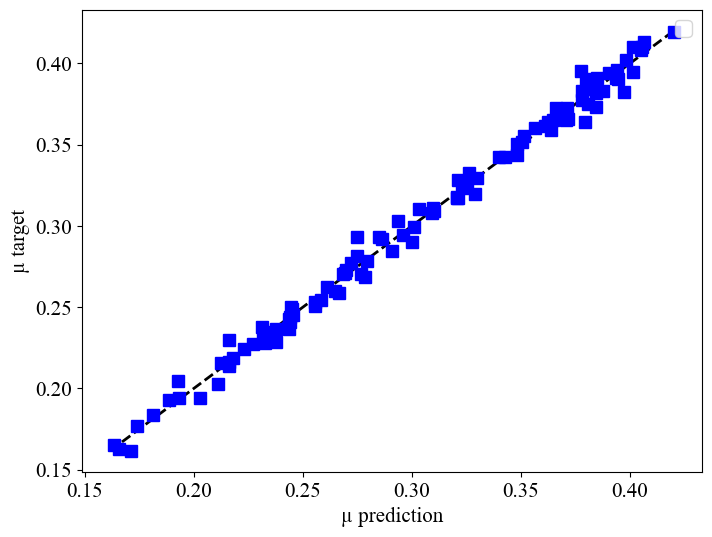

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\3317708640.py:686: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


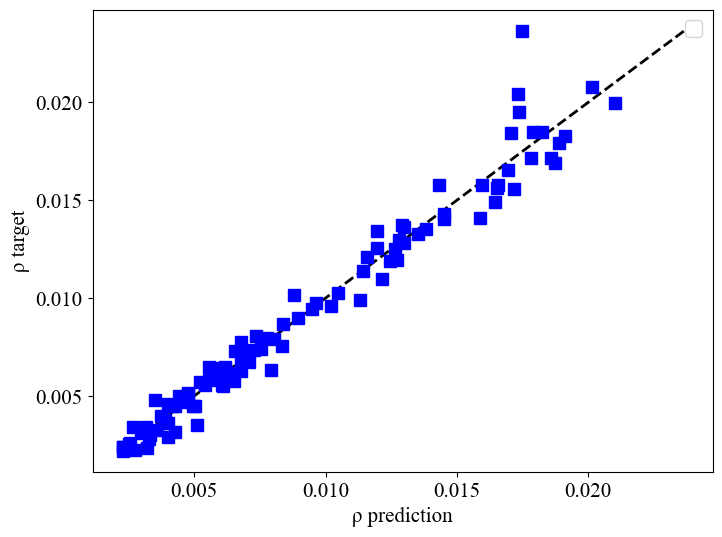

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 8]              32
         LeakyReLU-2                    [-1, 8]               0
            Linear-3                    [-1, 8]              72
         LeakyReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
Total params: 113
Trainable params: 113
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
net.0.weight: torch.Size([8, 3])
tensor([[-0.4963, -0.5444, -0.5345],
        [-0.0752, -0.2722, -0.0689],
        [ 0.2402,  0.3341, -0.3011],
        [ 0.1128,  0.1955,  0.5738],
        [ 0.4768, -0.0703,  0.4220],
        [ 0.2469, -0.481

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\3317708640.py:702: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("NN1_Model_weights.pth"))

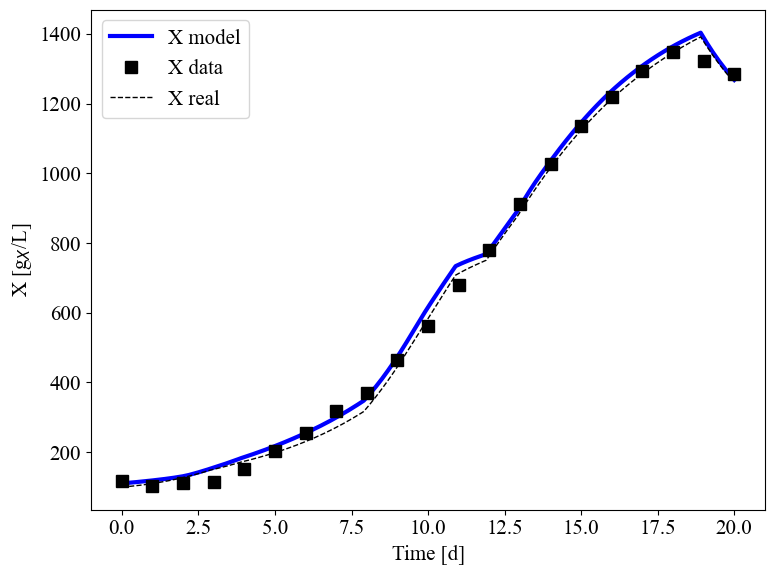

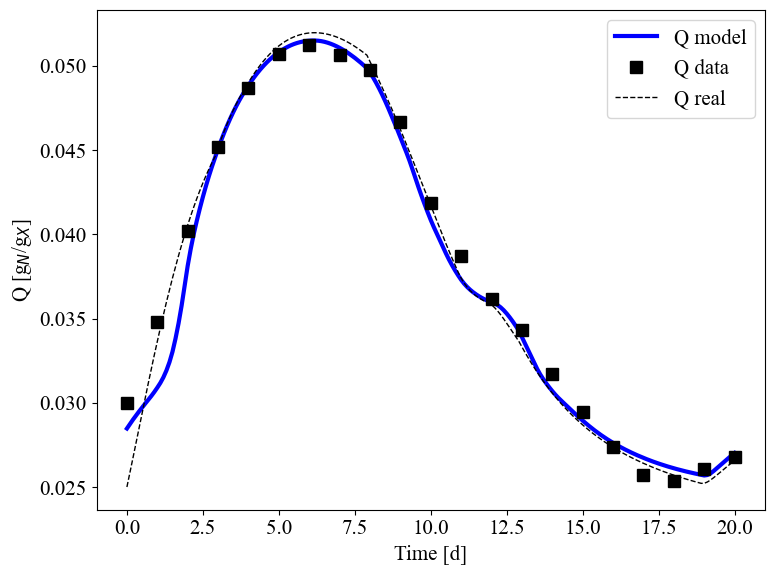

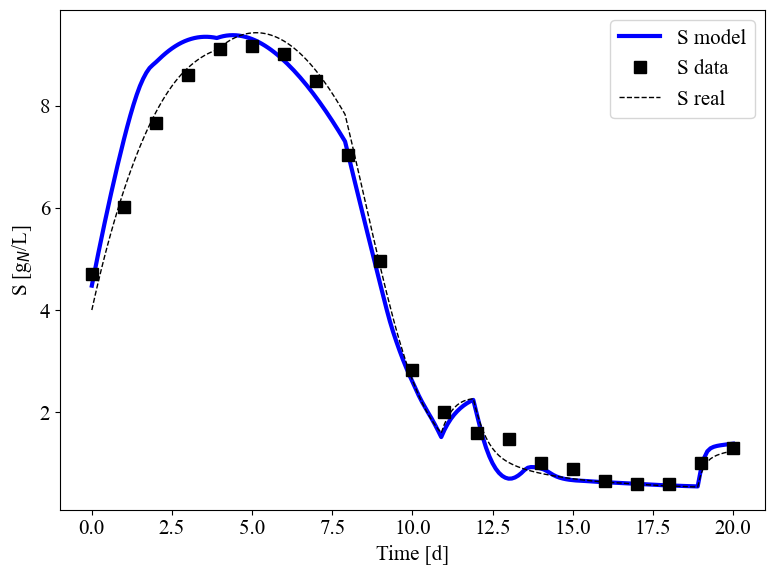

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\3317708640.py:825: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


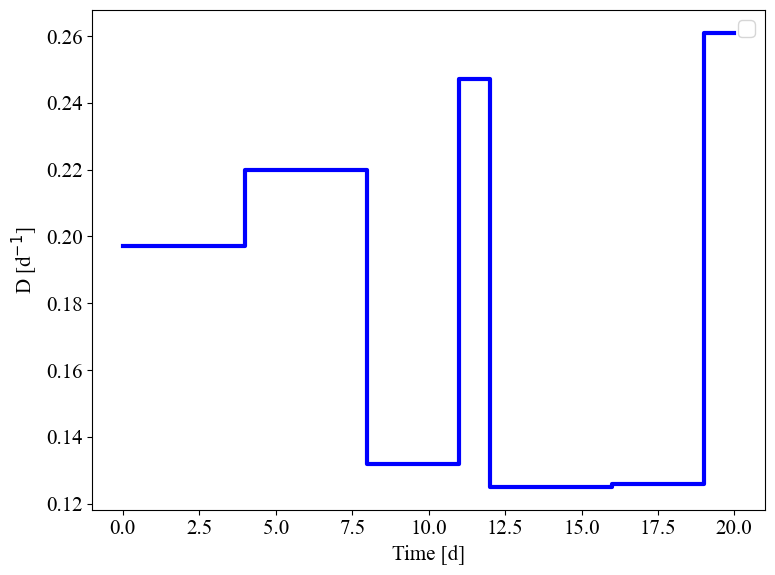

C:\Users\feder\AppData\Local\Temp\ipykernel_26012\3317708640.py:835: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


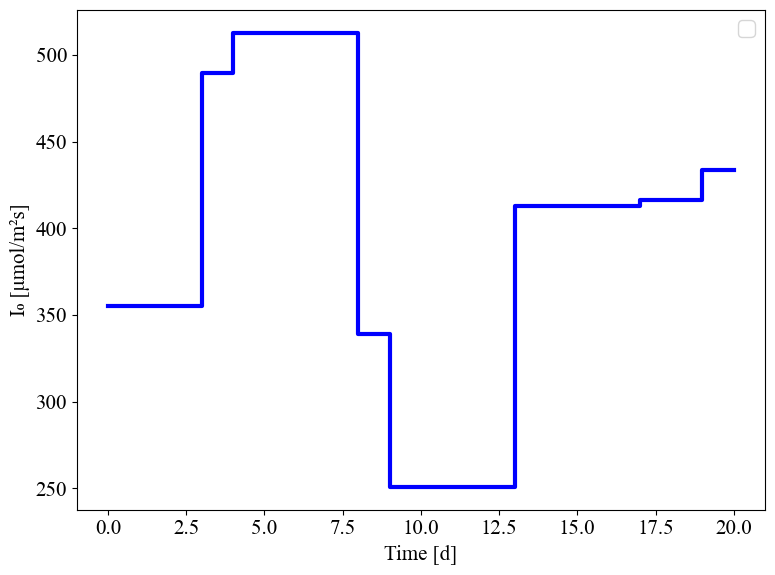

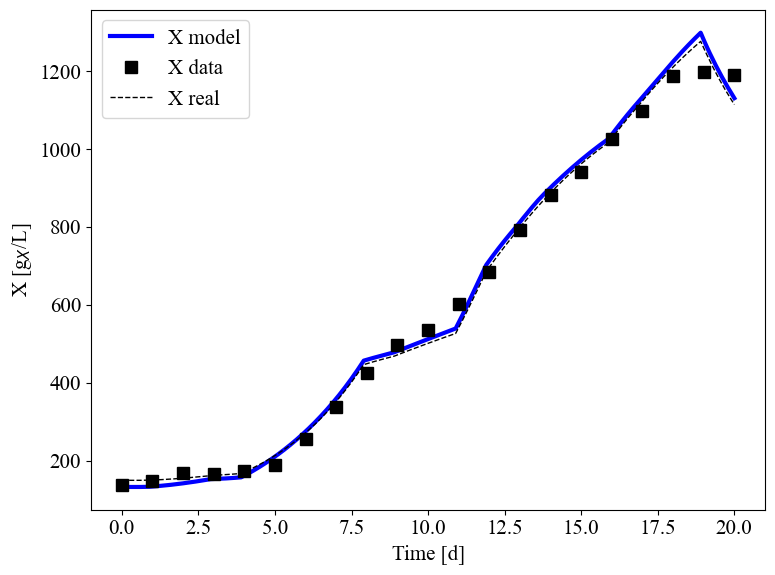

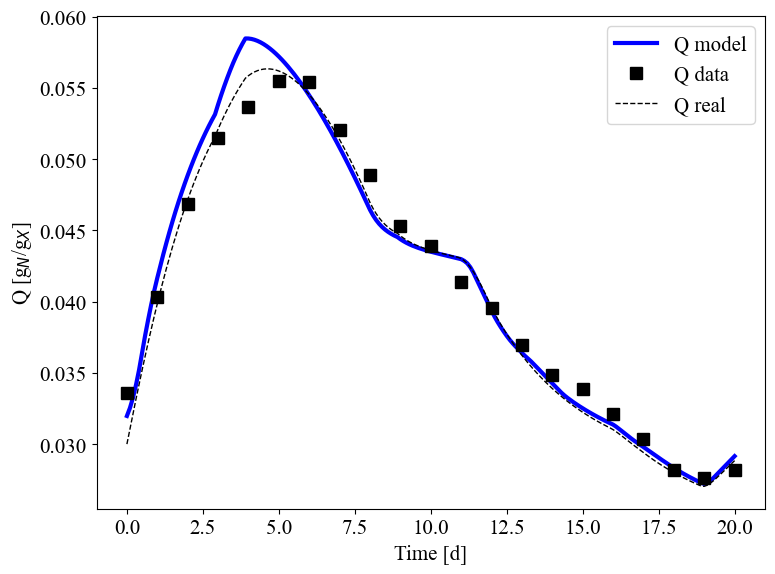

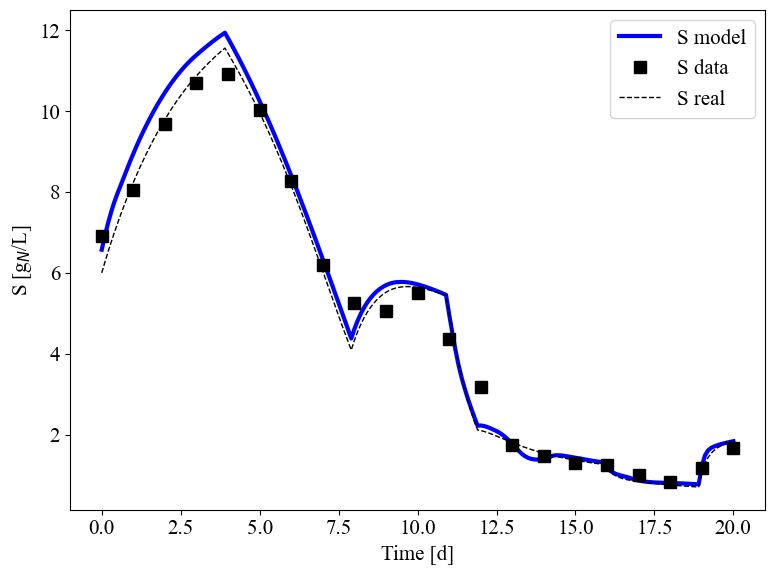

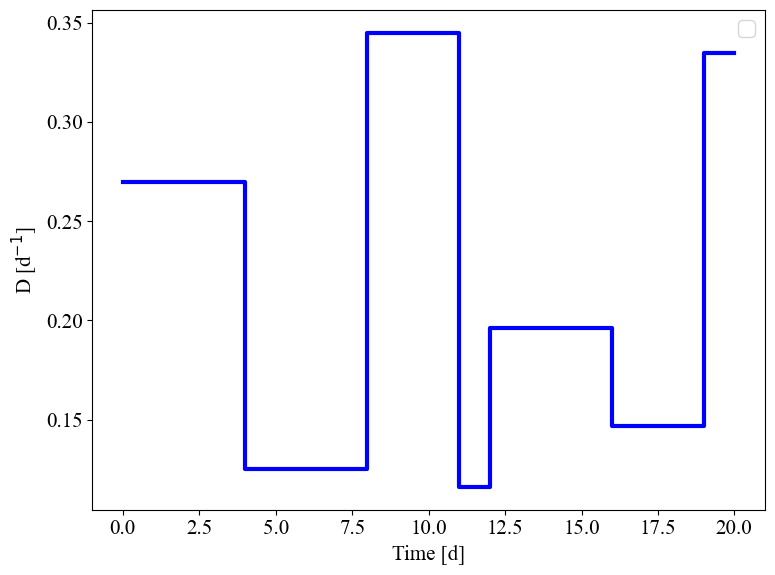

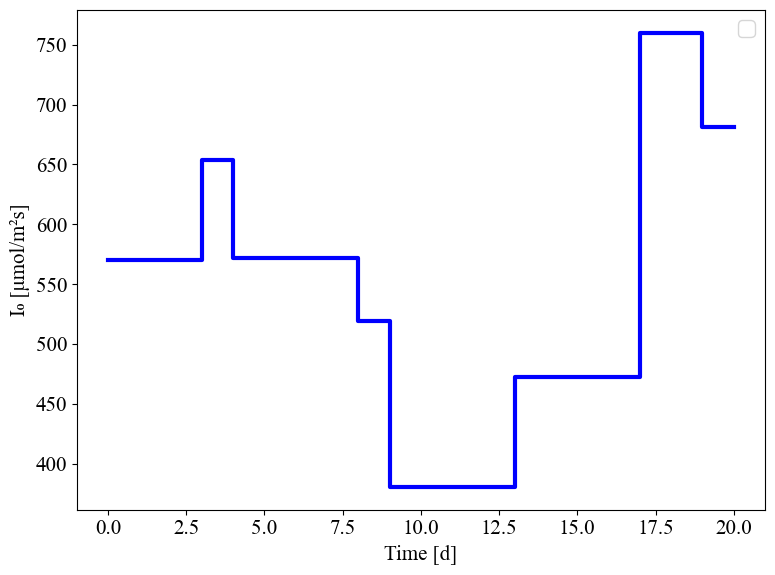

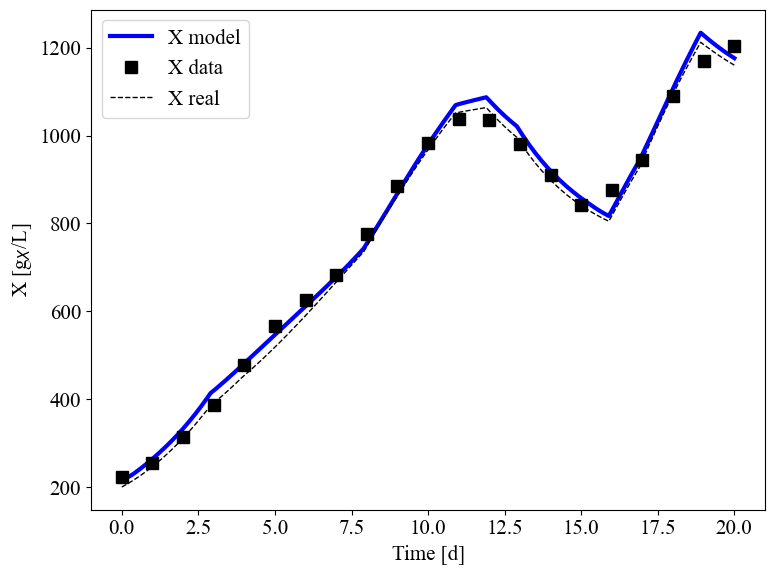

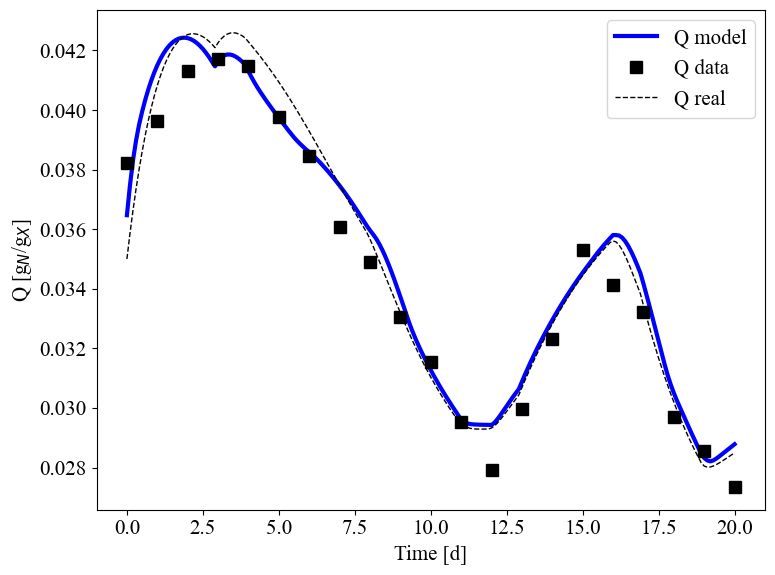

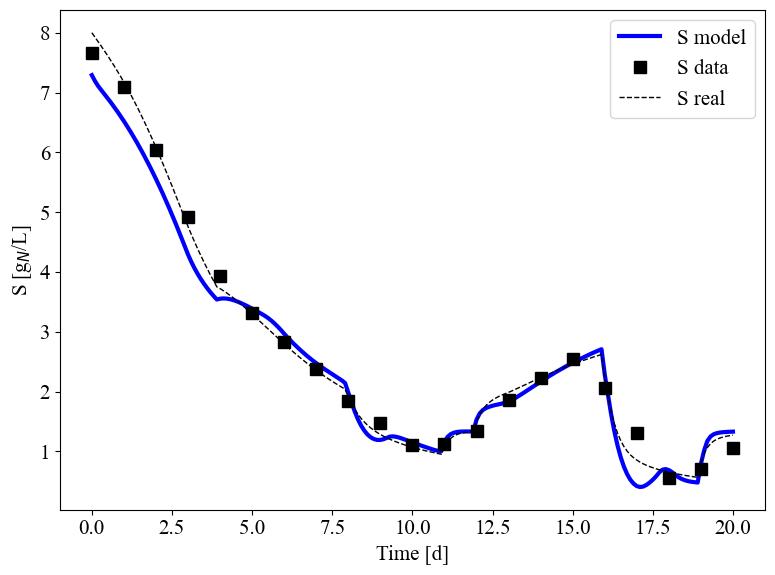

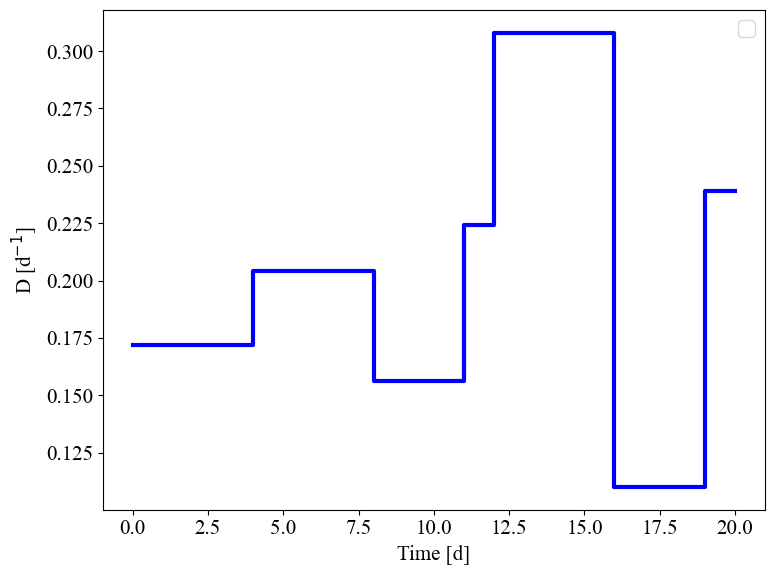

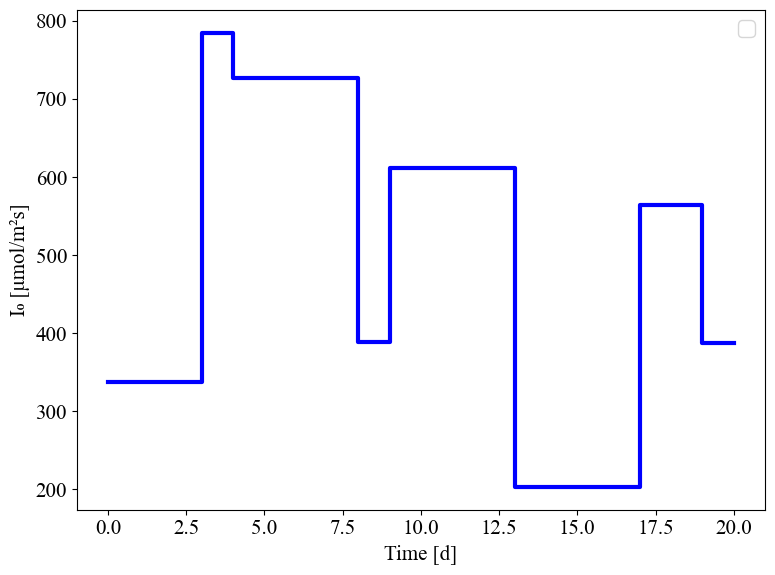

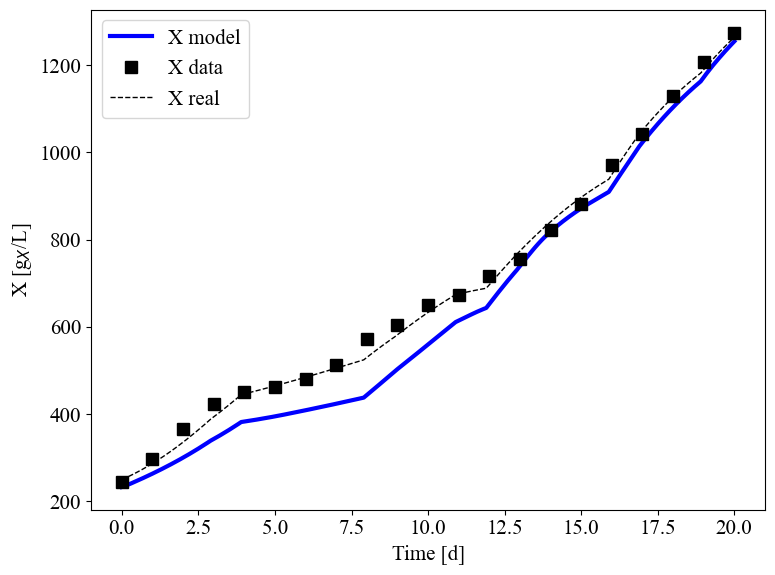

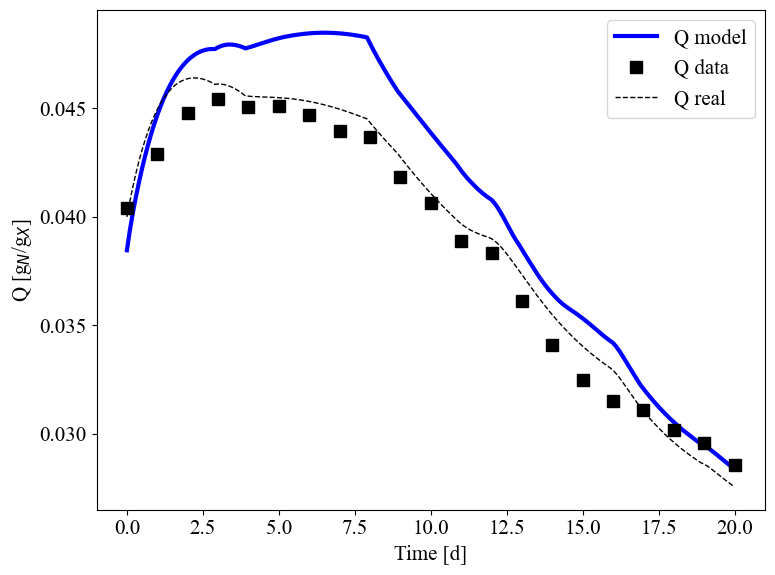

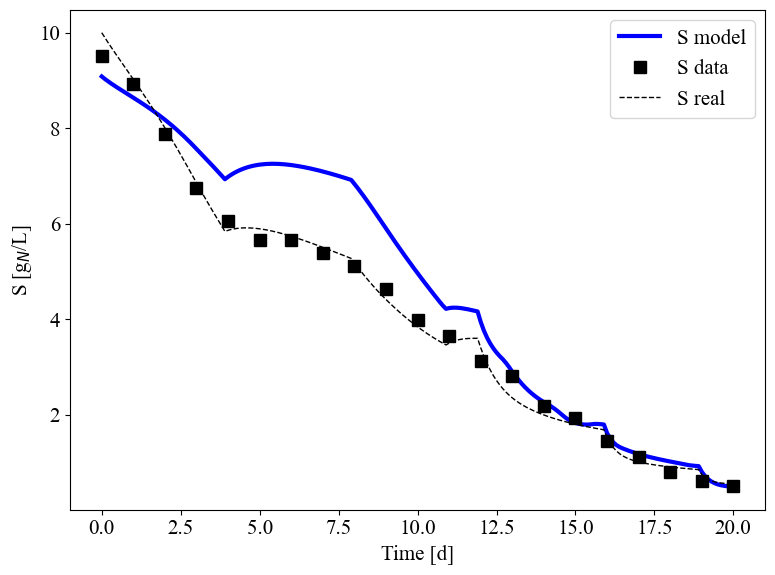

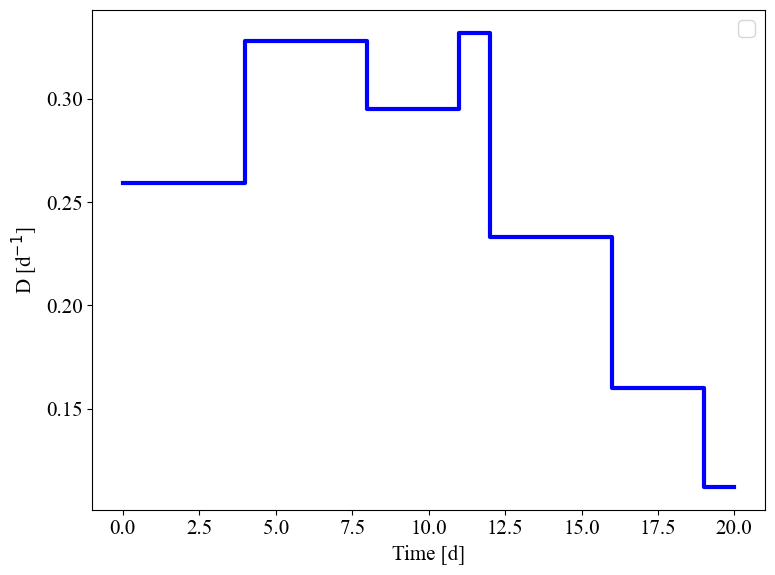

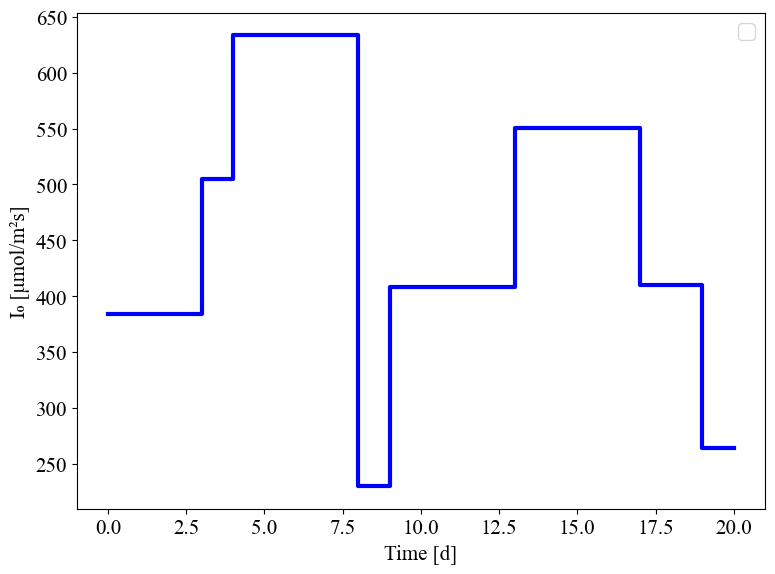

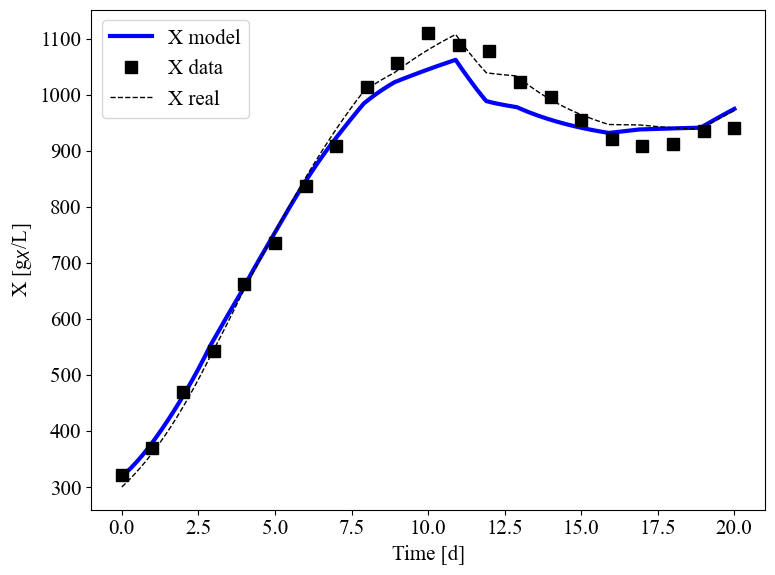

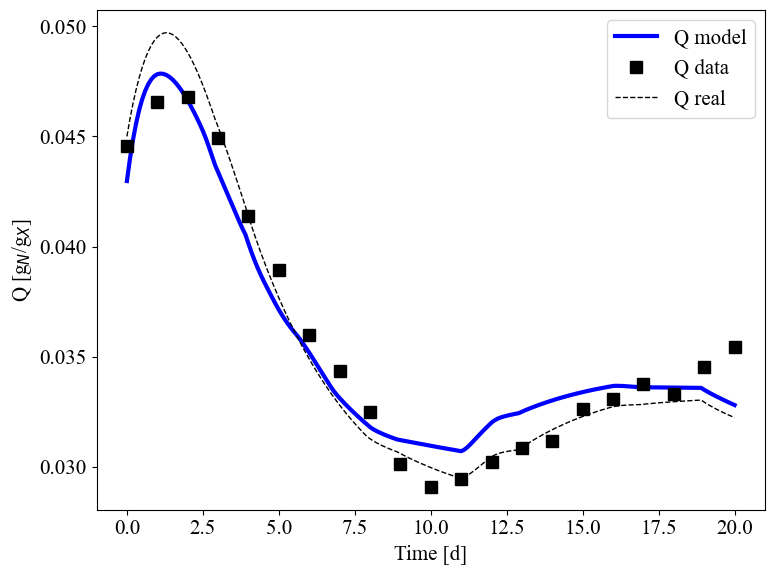

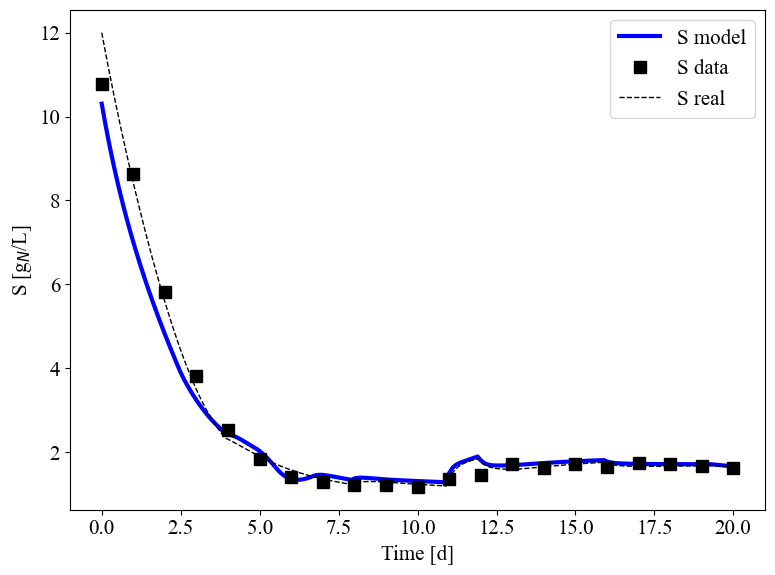

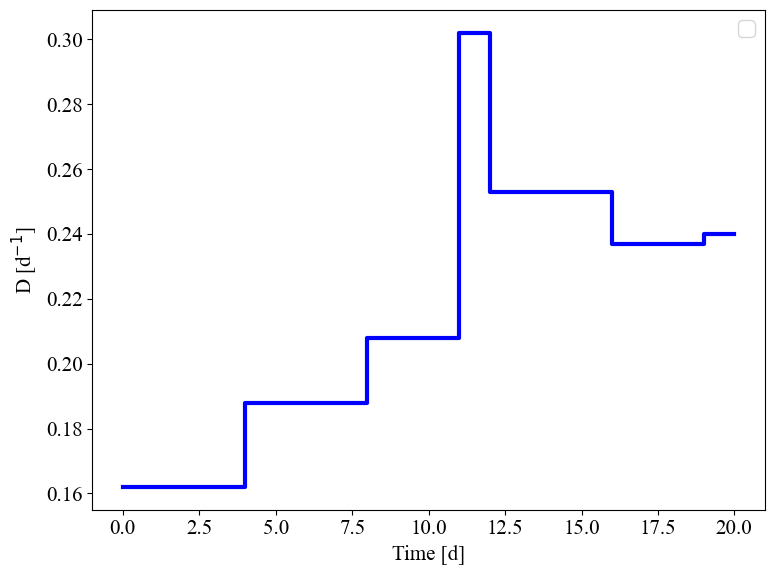

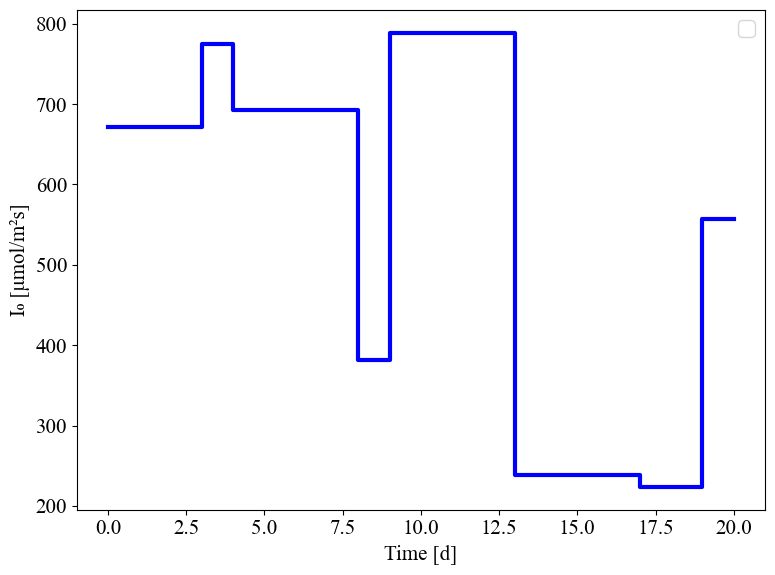

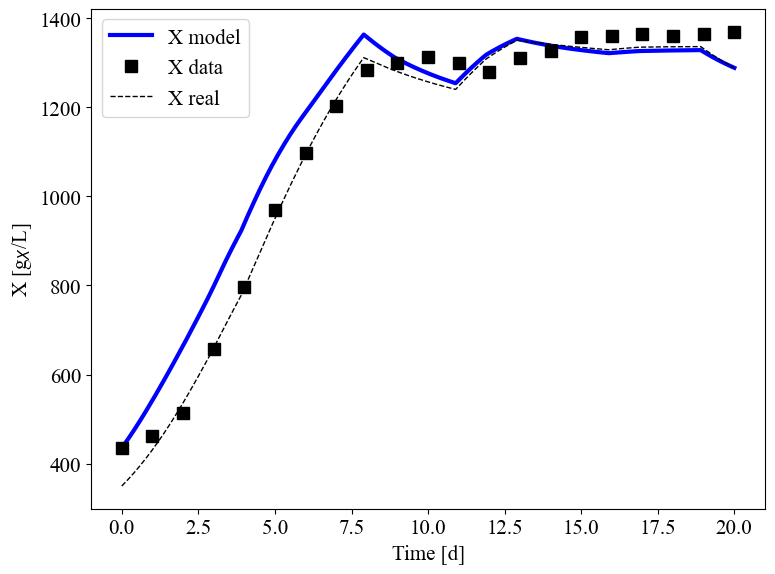

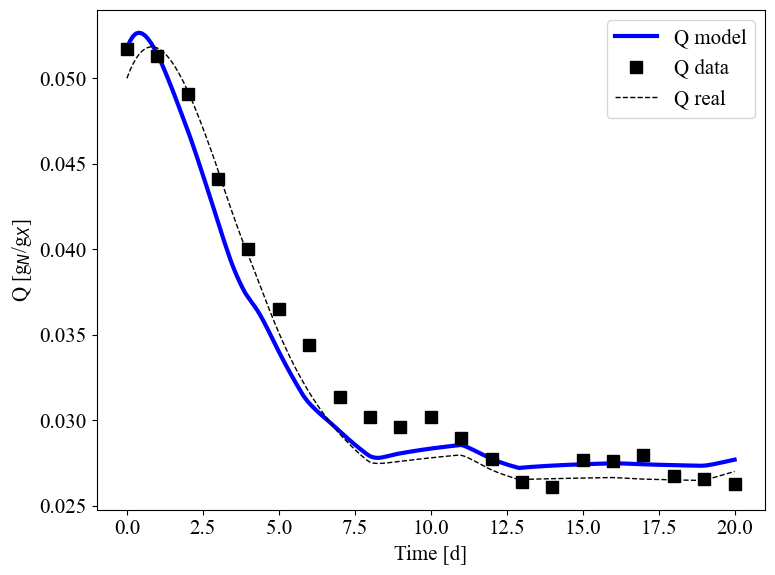

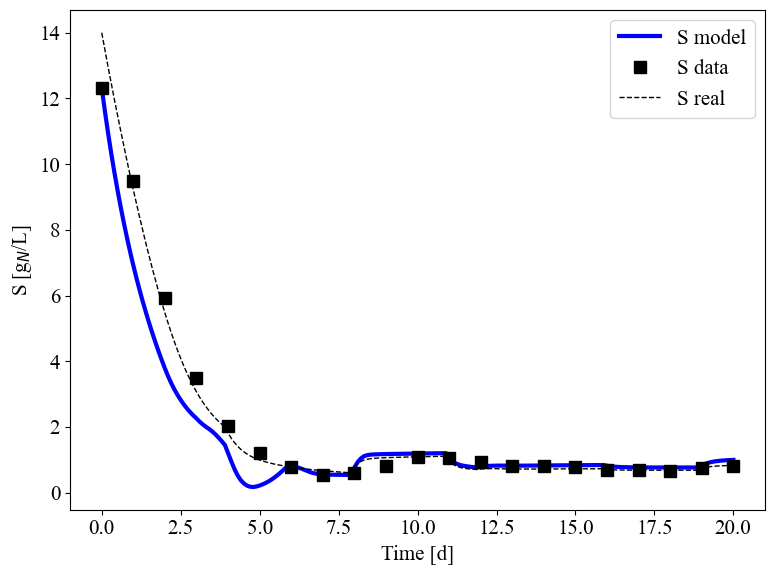

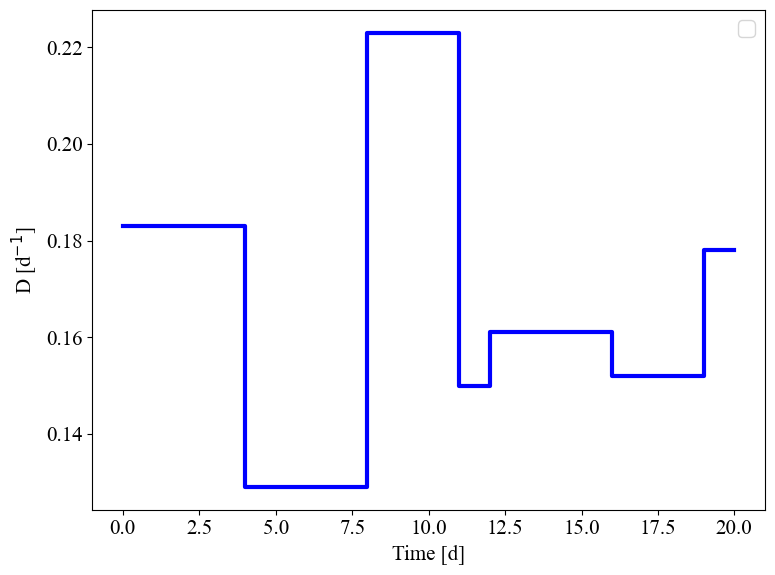

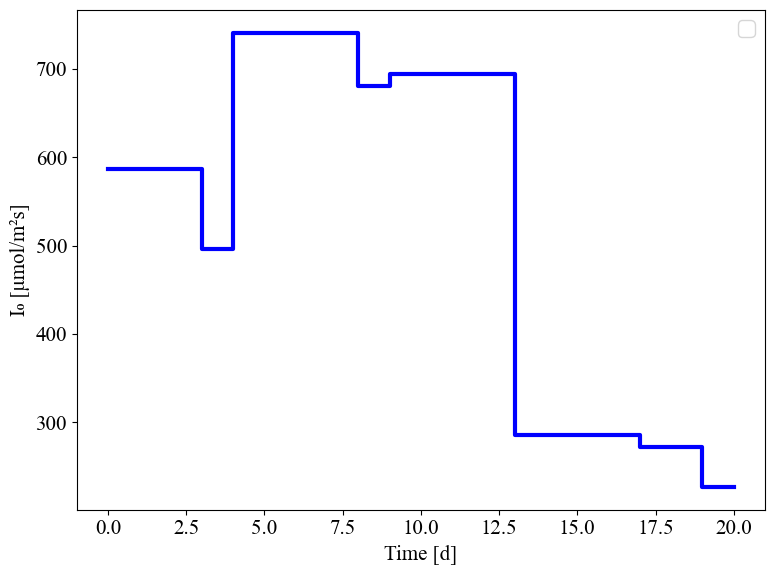


Relative Errors (Hybrid Model vs Measured Data):
Batch   Rel Error X   Rel Error Q   Rel Error S
    1        0.0713        0.0233        0.1119
    2        0.0583        0.0297        0.0809
    3        0.0300        0.0249        0.1182
    4        0.0967        0.0614        0.1639
    5        0.0287        0.0346        0.0873
    6        0.0720        0.0395        0.2012

Relative Errors (Hybrid Model vs Noise-Free System Data):
Batch   Rel Error X   Rel Error Q   Rel Error S
    1        0.0470        0.0217        0.1054
    2        0.0347        0.0178        0.0834
    3        0.0282        0.0122        0.1122
    4        0.0839        0.0450        0.1641
    5        0.0275        0.0310        0.0802
    6        0.0737        0.0298        0.2006

Standard deviations of the derivatives:
Standard deviation of dX/dt: 55.3189
Standard deviation of dQ/dt: 0.0030
Standard deviation of dS/dt: 1.2926


In [ ]:
# NN-BASED HYBRID MODEL 2025/03/05 03:20 PM (every *varying* days)
# (Process noise is added separately from measurement noise)

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import os

# Create directory for plots
os.makedirs('plots', exist_ok=True)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 15

# -------------------------------
# Utility: Rolling Average Smoothing
# -------------------------------
def rolling_average(signal, window_size):
    pad_width = window_size // 2
    padded_signal = np.pad(signal, pad_width, mode='edge')
    kernel = np.ones(window_size) / window_size
    return np.convolve(padded_signal, kernel, mode='valid')

# -------------------------------
# Configuration & Parameters
# -------------------------------
params = {
    'mu_tilde': 1.4846,
    'K_s': 10.954,
    'Q_0': 0.0089134,
    'Q_l': 0.13772,
    'rho_max': 0.058408,
    'R': 0.00723,  #0.00723,
    'K_sI_asterisk': 1.7983,
    'K_iI': 122.44,
    'gamma_max': 0.93005,
    'K_I_asterisk': 282.88,
    'a': 0.67014,
    'K_g': 10.67
}
S_in_base = 25  # Inlet substrate concentration

# Process noise level & corresponding sigma values
process_noise_level = 0.05
sigma_X = process_noise_level * 50    # For X
sigma_Q = process_noise_level * 0.0025  # For Q
sigma_S = process_noise_level * 1.30    # For S
# Standard deviations of the derivatives:
# Standard deviation of dX/dt: 43.1643
# Standard deviation of dQ/dt: 0.0032
# Standard deviation of dS/dt: 1.4370

total_batches = 6
t_max = 20      # days
n_steps = 21    # measurement points: t = 0,...,20
n_intervals = n_steps - 1  # 20 simulation intervals
t_eval = np.linspace(0, t_max, n_steps)

'''
# # -------------------------------
# # Generate Input Signals (D and I0)
# # -------------------------------
# # Adjust the number to generate random values for every # days
# def generate_input_matrix(n_steps, total_batches, min_value, max_value, seed=None):
#     if seed is not None:
#         np.random.seed(seed)
#     input_matrix = np.zeros((n_steps, total_batches))
#     for i in range(0, n_steps, 4):  # Generate random values for every # days
#         random_values = np.round(np.random.uniform(min_value, max_value, size=total_batches), 3)
#         input_matrix[i:i+4] = random_values # Generate random values for every # days
#     return input_matrix
'''

'''
# FIXED SPANS
def generate_input_matrix(n_steps, total_batches, min_value, max_value, period_length=4, seed=None):
    """
    Generate an input matrix where each row corresponds to a measurement point
    and each column corresponds to a batch. The input values remain constant for 
    a specified number of periods (period_length) before changing.

    Parameters:
    - n_steps: Total number of measurement points.
    - total_batches: Number of batches (columns).
    - min_value: Minimum value for the random input.
    - max_value: Maximum value for the random input.
    - period_length: Number of periods each random value is held constant.
 
    Returns:
    - input_matrix: A matrix of shape (n_steps, total_batches) with block-wise constant random values.
    """

    if seed is not None:
        np.random.seed(seed)

    # Determine the number of periods needed (round up for incomplete final period)
    num_periods = int(np.ceil(n_steps / period_length))
    
    # Generate one random value per period for each batch
    random_values = np.round(np.random.uniform(min_value, max_value, size=(num_periods, total_batches)), 3)
    
    # Repeat each random value 'period_length' times along the rows
    input_matrix = np.repeat(random_values, period_length, axis=0)[:n_steps]
    
    # Always set the last row equal to the penultimate row (if available)
    if n_steps > 1:
        input_matrix[-1] = input_matrix[-2]

    return input_matrix
'''

# '''
# CHANGING SPANS
def generate_input_matrix(n_steps, total_batches, min_value, max_value, min_period=1, max_period=4, seed=None):
    """
    Generate an input matrix where each row corresponds to a measurement point
    and each column corresponds to a batch. The input values are constant over 
    periods whose lengths vary randomly between 'min_period' and 'max_period'. 
    When a period starts, a random duration is selected, and a random value is 
    generated for that period across all batches. Regardless of the period 
    structure, the final row is always set equal to the penultimate row.
    
    Parameters:
    - n_steps: Total number of measurement points (rows).
    - total_batches: Number of batches (columns).
    - min_value: Minimum value for the random input.
    - max_value: Maximum value for the random input.
    - min_period: Minimum duration (in steps) that a random value is held constant.
    - max_period: Maximum duration (in steps) that a random value is held constant.
    - seed: Seed for the random number generator for reproducibility.
    
    Returns:
    - input_matrix: A matrix of shape (n_steps, total_batches) with block-wise constant random values,
        where the last row replicates the penultimate row.
    """
    
    if seed is not None:
        np.random.seed(seed)

    blocks = []
    steps_generated = 0

    # Keep generating blocks until we reach at least n_steps rows
    while steps_generated < n_steps:
        # Choose a random period length between min_period and max_period (inclusive)
        period_length = np.random.randint(min_period, max_period + 1)
        # Generate one random value per batch for this period
        random_values = np.round(np.random.uniform(min_value, max_value, size=(1, total_batches)), 3)
        # Create a block that repeats the random value for the chosen period length
        block = np.repeat(random_values, period_length, axis=0)
        blocks.append(block)
        steps_generated += period_length

    # Concatenate all blocks and trim to exactly n_steps rows
    input_matrix = np.concatenate(blocks, axis=0)[:n_steps]
    
    # Always set the final row equal to the penultimate row (if there is more than one row)
    if n_steps > 1:
        input_matrix[-1] = input_matrix[-2]
    
    return input_matrix
# '''

'''
# SYNCRONIZED CHANGING SPANS
def generate_input_matrix(n_steps, total_batches, min_value, max_value, min_period=1, max_period=4, 
                          seed_period=None, seed_value=None):
    """
    Generate an input matrix where each row corresponds to a measurement point
    and each column corresponds to a batch. For each batch, the input values remain 
    constant over periods whose lengths vary randomly between 'min_period' and 'max_period'. 
    A separate seed is used for period length selection and for random value generation.
    Regardless of the period structure, the final value for each batch is always set equal 
    to its penultimate value.
    
    Parameters:
    - n_steps: int
        Total number of measurement points (rows).
    - total_batches: int
        Number of batches (columns).
    - min_value: float
        Minimum value for the random input.
    - max_value: float
        Maximum value for the random input.
    - min_period: int, optional (default=1)
        Minimum duration (in steps) that a random value is held constant.
    - max_period: int, optional (default=4)
        Maximum duration (in steps) that a random value is held constant.
    - seed_period: int, optional (default=None)
        Seed for the random number generator controlling period lengths.
    - seed_value: int, optional (default=None)
        Seed for the random number generator controlling value generation.
    
    Returns:
    - input_matrix: numpy.ndarray
        A matrix of shape (n_steps, total_batches) with independently generated, block-wise 
        constant random values for each batch, where the final row in each column replicates 
        the penultimate row.
    """
    
    # Initialize independent random generators for period and value
    rng_period = np.random.default_rng(seed_period)
    rng_value = np.random.default_rng(seed_value)
    
    # List to hold generated columns (one per batch)
    columns = []
    
    # Generate data for each batch independently
    for batch in range(total_batches):
        batch_data = []
        steps_generated = 0
        
        # Generate blocks until we have at least n_steps values
        while steps_generated < n_steps:
            # Choose a random period length for the current batch
            period_length = rng_period.integers(min_period, max_period + 1)
            # Generate one random value for this period (rounded for consistency)
            random_value = np.round(rng_value.uniform(min_value, max_value), 3)
            # Extend the current batch data with this value repeated for period_length steps
            batch_data.extend([random_value] * period_length)
            steps_generated += period_length
        
        # Trim the column to exactly n_steps entries
        batch_data = batch_data[:n_steps]
        
        # Always set the last value equal to the penultimate value (if there is more than one entry)
        if n_steps > 1:
            batch_data[-1] = batch_data[-2]
        
        # Append this batch column as a NumPy array
        columns.append(np.array(batch_data))
    
    # Combine the columns to form the full input matrix (each column is a batch)
    input_matrix = np.column_stack(columns)
    
    return input_matrix
'''
min_value = 0.100
max_value = 0.350
D_matrix = generate_input_matrix(n_steps, total_batches, min_value, max_value, seed=89)
print(D_matrix)

min_value = 200
max_value = 800
I0_matrix = generate_input_matrix(n_steps, total_batches, min_value, max_value, seed=95)
print(I0_matrix)


# Use first 20 rows for simulation inputs.
D_sim = D_matrix[:n_intervals, :]
I0_sim = I0_matrix[:n_intervals, :]

# -------------------------------
# Deterministic Process Model (Noise-Free)
# -------------------------------
def deterministic_model(t, x, D, I0, S_in):
    X, Q, S = x
    gamma = params['gamma_max'] * (params['K_I_asterisk'] / (params['K_I_asterisk'] + I0))
    Chl = gamma * X * Q
    theta_cell = Chl / X
    K_sI = params['K_sI_asterisk'] / theta_cell
    I_opt = np.sqrt(K_sI * params['K_iI'])
    xi = params['a'] * X
    L = 0.10
    I_overline = I0 * params['K_g'] / (params['K_g'] + (xi * L))
    mu = params['mu_tilde'] * I_overline / (K_sI + I_overline + (I_overline**2 / params['K_iI'])) * (1 - (params['Q_0'] / Q))
    rho = params['rho_max'] * (S / (params['K_s'] + S)) * (1 - (Q / params['Q_l']))
    X_dot = mu * X - params['R'] * X - D * X
    Q_dot = rho - mu * (Q - params['Q_0'])
    S_dot = D * (S_in - S) - rho * X
    if S <= 0:
        S_dot = 0
    return [X_dot, Q_dot, S_dot]

# -------------------------------
# 1. Data Generation (New Structure)
# -------------------------------
# We will generate:
#   - x_system (noise-free process data)
#   - x_noise (process noise at each time instant)
#   - x_system_noise = x_system + x_noise
#   - y_noise (measurement noise)
#   - y_system_noise = x_system_noise + y_noise
# And for each measurement time, the derivative target is computed as:
#   deterministic_model(...) + derivative noise.
window_size = 3

# Lists to store data for all batches
X_system_list = []
Q_system_list = []
S_system_list = []
X_data_list = []  # final (smoothed measured) X
Q_data_list = []  # final (smoothed measured) Q
S_data_list = []  # final (smoothed measured) S
dX_dt_data_list = []  # derivative targets for X
dQ_dt_data_list = []  # derivative targets for Q
dS_dt_data_list = []  # derivative targets for S
t_data_list = []
D_data_list = []
I0_data_list = []
batch_indices_list = []
real_ICs = []       # noise-free initial conditions
measured_ICs = []   # measured initial conditions
deriv_deterministic_list = []  # to store deterministic derivatives (without noise)

for i in range(total_batches):
    # Define noise-free initial conditions
    initial_conditions = np.array([50, 0.020, 2]) + (i + 1) * np.array([50, 0.005, 2])
    real_ICs.append(initial_conditions)
    x0 = initial_conditions.copy()
    
    # Get input signals for the batch
    D_i = D_sim[:, i]
    I0_i = I0_sim[:, i]
    D_i_pad = np.concatenate((D_i, [D_i[-1]]))
    I0_i_pad = np.concatenate((I0_i, [I0_i[-1]]))
    
    # Generate noise-free trajectory (x_system) via integration
    x_sys = [x0]
    for j in range(n_intervals):
        t_local = (t_eval[j], t_eval[j+1])
        D_val = D_i[j]
        I0_val = I0_i[j]
        sol = solve_ivp(lambda t, x: deterministic_model(t, x, D_val, I0_val, S_in_base),
                        t_local, x_sys[-1], t_eval=[t_eval[j], t_eval[j+1]])
        x_sys.append(sol.y[:, -1])
    x_sys = np.array(x_sys)  # shape: (n_steps, 3)
    
    # Save the noise-free trajectory for reference
    X_system_list.append(x_sys[:, 0])
    Q_system_list.append(x_sys[:, 1])
    S_system_list.append(x_sys[:, 2])
    
    # Generate process noise (x_noise) for each measurement time
    proc_noise = np.zeros_like(x_sys)
    proc_noise[:, 0] = sigma_X * np.random.randn(n_steps)
    proc_noise[:, 1] = sigma_Q * np.random.randn(n_steps)
    proc_noise[:, 2] = sigma_S * np.random.randn(n_steps)
    
    # Process data with noise: x_system_noise = x_system + process noise
    x_sys_noise = x_sys + proc_noise
    
    # Compute derivative targets:
    # For each measurement time, evaluate the deterministic model (using smoothed D, I0) and add derivative noise.
    deriv_det = []
    deriv_target = []
    D_smooth = rolling_average(D_i_pad, window_size)
    I0_smooth = rolling_average(I0_i_pad, window_size)
    for j in range(n_steps):
        deriv_det_j = np.array(deterministic_model(t_eval[j], x_sys[j], D_smooth[j], I0_smooth[j], S_in_base))
        deriv_det.append(deriv_det_j)
        # Derivative noise generated independently
        deriv_noise = np.array([sigma_X * np.random.randn(), sigma_Q * np.random.randn(), sigma_S * np.random.randn()])
        deriv_target.append(deriv_det_j + deriv_noise)
    deriv_det = np.array(deriv_det).T  # shape: (3, n_steps)
    deriv_target = np.array(deriv_target).T  # shape: (3, n_steps)
    deriv_deterministic_list.append(deriv_det)
    
    # Generate measurement noise (y_noise)
    meas_noise = np.zeros_like(x_sys)
    X_meas_std = 0.04 * np.mean(x_sys_noise[:, 0])
    Q_meas_std = 0.04 * np.mean(x_sys_noise[:, 1])
    S_meas_std = 0.04 * np.mean(x_sys_noise[:, 2])
    meas_noise[:, 0] = np.random.normal(0, X_meas_std, n_steps)
    meas_noise[:, 1] = np.random.normal(0, Q_meas_std, n_steps)
    meas_noise[:, 2] = np.random.normal(0, S_meas_std, n_steps)
    
    # Measured system data: y_system_noise = x_system_noise + measurement noise
    y_sys = x_sys_noise + meas_noise
    y_sys[:, 0] = np.clip(y_sys[:, 0], 0, None)
    y_sys[:, 1] = np.clip(y_sys[:, 1], 0, None)
    y_sys[:, 2] = np.clip(y_sys[:, 2], 0, None)
    
    measured_ICs.append(y_sys[0])
    
    # Smooth the measured data
    y_sys_smooth = np.zeros_like(y_sys)
    y_sys_smooth[:, 0] = rolling_average(y_sys[:, 0], window_size)
    y_sys_smooth[:, 1] = rolling_average(y_sys[:, 1], window_size)
    y_sys_smooth[:, 2] = rolling_average(y_sys[:, 2], window_size)
    
    # Append data for training
    X_data_list.append(y_sys_smooth[:, 0])
    Q_data_list.append(y_sys_smooth[:, 1])
    S_data_list.append(y_sys_smooth[:, 2])
    dX_dt_data_list.append(deriv_target[0, :])
    dQ_dt_data_list.append(deriv_target[1, :])
    dS_dt_data_list.append(deriv_target[2, :])
    t_data_list.append(t_eval)
    D_data_list.append(D_smooth)
    I0_data_list.append(I0_smooth)
    batch_indices_list.extend([i + 1] * n_steps)

# Combine arrays across batches
X_data = np.concatenate(X_data_list)
Q_data = np.concatenate(Q_data_list)
S_data = np.concatenate(S_data_list)
dX_dt_data = np.concatenate(dX_dt_data_list)
dQ_dt_data = np.concatenate(dQ_dt_data_list)
dS_dt_data = np.concatenate(dS_dt_data_list)
t_data = np.concatenate(t_data_list)
D_data = np.concatenate(D_data_list)
I0_data = np.concatenate(I0_data_list)
batch_indices = np.array(batch_indices_list)

# Global noise-free (deterministic) system data for reference
X_system_data = np.concatenate(X_system_list)
Q_system_data = np.concatenate(Q_system_list)
S_system_data = np.concatenate(S_system_list)

# -------------------------------
# 2. Data Preparation & Normalization
# -------------------------------
k_fold_batches = [1, 2, 3, 4, 5]
external_batch = [6]
training_batches = k_fold_batches

X_data_tensor = torch.tensor(np.vstack((X_data, Q_data, S_data, D_data, I0_data)).T, dtype=torch.float32)
dX_dt_data_tensor = torch.tensor(np.vstack((dX_dt_data, dQ_dt_data, dS_dt_data)).T, dtype=torch.float32)

external_mask = np.isin(batch_indices, external_batch)
X_external = X_data_tensor[external_mask]
dX_dt_external = dX_dt_data_tensor[external_mask]
t_external = t_data[external_mask]

# -------------------------------
# 3. Neural Network Models and Utility Functions
# -------------------------------
class NN1_Model(nn.Module):
    def __init__(self):
        super(NN1_Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        X = x[:, 0:1]
        Q = x[:, 1:2]
        I0 = x[:, 4:5]
        return self.net(torch.cat((X, Q, I0), dim=1))

class NN2_Model(nn.Module):
    def __init__(self):
        super(NN2_Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        Q = x[:, 1:2]
        S = x[:, 2:3]
        return self.net(torch.cat((Q, S), dim=1))

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            m.bias.data.fill_(0.01)

criterion = nn.MSELoss()

def dynamics(x, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std):
    x_in = torch.cat([x, torch.tensor([[D_val, I0_val]], dtype=torch.float32, device=x.device)], dim=1)
    x_in_norm = (x_in - input_mean) / input_std
    mu_pred_norm = model_NN1_final(x_in_norm)
    mu_pred = mu_pred_norm * mu_target_std + mu_target_mean
    rho_pred_norm = model_NN2_final(x_in_norm)
    rho_pred = rho_pred_norm * rho_target_std + rho_target_mean
    X_prev = x[:, 0:1]
    Q_prev = x[:, 1:2]
    S_prev = x[:, 2:3]
    dX_dt = X_prev * (mu_pred - D_val)
    dQ_dt = rho_pred - mu_pred * (Q_prev - params['Q_0'])
    dS_dt = D_val * (S_in_base - S_prev) - rho_pred * X_prev
    return torch.cat((dX_dt, dQ_dt, dS_dt), dim=1)

def rk4_step(x, D_val, I0_val, dt, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std):
    k1 = dynamics(x, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    k2 = dynamics(x + dt/2 * k1, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    k3 = dynamics(x + dt/2 * k2, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    k4 = dynamics(x + dt * k3, D_val, I0_val, input_mean, input_std, mu_target_mean, mu_target_std, rho_target_mean, rho_target_std)
    x_next = x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return torch.clamp(x_next, min=0)

# Deterministic RK4 integration (noise-free) for state prediction reference
def rk4_step_real(x, D_val, I0_val, dt, S_in):
    k1 = np.array(deterministic_model(0, x, D_val, I0_val, S_in))
    k2 = np.array(deterministic_model(0, x + dt/2 * k1, D_val, I0_val, S_in))
    k3 = np.array(deterministic_model(0, x + dt/2 * k2, D_val, I0_val, S_in))
    k4 = np.array(deterministic_model(0, x + dt * k3, D_val, I0_val, S_in))
    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# -------------------------------
# 4. Iterative Loop for Hybrid Training and Initial Condition Identification
# -------------------------------
epochs = 20001
batch_size = 256
epsilon = 1e-8
iterations = 3
final_identified_ICs = {}

for it in range(iterations):
    print(f"\n=== Iteration {it+1} of {iterations} ===")
    final_mask = np.isin(batch_indices, training_batches)
    X_train_final = X_data_tensor[final_mask]
    dX_dt_train_final = dX_dt_data_tensor[final_mask]
    
    input_mean_final = X_train_final.mean(dim=0)
    input_std_final = X_train_final.std(dim=0)
    target_mean_final = dX_dt_train_final.mean(dim=0)
    target_std_final = dX_dt_train_final.std(dim=0)
    input_std_final[input_std_final == 0] = 1.0
    target_std_final[target_std_final == 0] = 1.0
    
    X_train_final_norm = (X_train_final - input_mean_final) / input_std_final
    dX_dt_train_final_norm = (dX_dt_train_final - target_mean_final) / target_std_final
    
    data_train_final = X_train_final.numpy()
    deriv_train_final = dX_dt_train_final.numpy()
    mu_target_train_final = (deriv_train_final[:, 0:1] / (data_train_final[:, 0:1] + epsilon)) + data_train_final[:, 3:4]
    rho_target_train_final = (data_train_final[:, 3:4]*(S_in_base - data_train_final[:, 2:3]) - deriv_train_final[:, 2:3]) / (data_train_final[:, 0:1] + epsilon)
    mu_target_mean_final = mu_target_train_final.mean(axis=0)
    mu_target_std_final = mu_target_train_final.std(axis=0)
    mu_target_std_final[mu_target_std_final == 0] = 1.0
    rho_target_mean_final = rho_target_train_final.mean(axis=0)
    rho_target_std_final = rho_target_train_final.std(axis=0)
    rho_target_std_final[rho_target_std_final == 0] = 1.0
    
    mu_target_train_final_norm = (mu_target_train_final - mu_target_mean_final) / mu_target_std_final
    rho_target_train_final_norm = (rho_target_train_final - rho_target_mean_final) / rho_target_std_final
    mu_target_train_final_norm = torch.tensor(mu_target_train_final_norm, dtype=torch.float32)
    rho_target_train_final_norm = torch.tensor(rho_target_train_final_norm, dtype=torch.float32)
    
    # Train NN1
    model_NN1_final = NN1_Model()
    model_NN1_final.apply(init_weights)
    optimizer_NN1_final = optim.Adam(model_NN1_final.parameters(), lr=1e-4)
    n_train_final = X_train_final_norm.shape[0]
    num_train_batches = int(np.ceil(n_train_final / batch_size))
    
    for epoch in range(epochs):
        model_NN1_final.train()
        permutation = torch.randperm(n_train_final)
        epoch_loss = 0.0
        for i_batch in range(0, n_train_final, batch_size):
            indices_batch = permutation[i_batch:i_batch+batch_size]
            batch_X = X_train_final_norm[indices_batch]
            batch_target = mu_target_train_final_norm[indices_batch]
            optimizer_NN1_final.zero_grad()
            pred = model_NN1_final(batch_X)
            loss = criterion(pred, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_NN1_final.parameters(), max_norm=1.0)
            optimizer_NN1_final.step()
            epoch_loss += loss.item()
        if epoch % 5000 == 0:
            print(f'NN1 - Epoch {epoch}, Loss: {epoch_loss/num_train_batches:.6f}')
    
    # Train NN2
    model_NN2_final = NN2_Model()
    model_NN2_final.apply(init_weights)
    optimizer_NN2_final = optim.Adam(model_NN2_final.parameters(), lr=1e-4)
    
    for epoch in range(epochs):
        model_NN2_final.train()
        permutation = torch.randperm(n_train_final)
        epoch_loss = 0.0
        for i_batch in range(0, n_train_final, batch_size):
            indices_batch = permutation[i_batch:i_batch+batch_size]
            batch_X = X_train_final_norm[indices_batch]
            batch_target = rho_target_train_final_norm[indices_batch]
            optimizer_NN2_final.zero_grad()
            pred = model_NN2_final(batch_X)
            loss = criterion(pred, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_NN2_final.parameters(), max_norm=1.0)
            optimizer_NN2_final.step()
            epoch_loss += loss.item()
        if epoch % 5000 == 0:
            print(f'NN2 - Epoch {epoch}, Loss: {epoch_loss/num_train_batches:.6f}')
    
    input_mean_np = input_mean_final.detach().numpy()
    input_std_np = input_std_final.detach().numpy()
    mu_target_mean_np = mu_target_mean_final
    mu_target_std_np = mu_target_std_final
    rho_target_mean_np = rho_target_mean_final
    rho_target_std_np = rho_target_std_final

    if it != iterations - 1:
        identified_initial_conditions = {}
        for batch_number in training_batches:
            indices = np.where(batch_indices == batch_number)[0]
            meas_states = np.vstack((X_data[indices], Q_data[indices], S_data[indices])).T
            target_states = meas_states
            t_batch = t_data[indices]
            n_steps_batch = len(t_batch)
            dt_meas = t_batch[1] - t_batch[0]
            D_i_batch = D_data[:n_steps_batch]
            I0_i_batch = I0_data[:n_steps_batch]
            
            def ic_cost(ic_candidate):
                ic_tensor = torch.tensor(ic_candidate, dtype=torch.float32)
                x_sim = ic_tensor.unsqueeze(0)
                sim_states = [x_sim]
                for k in range(1, n_steps_batch):
                    D_val = D_i_batch[k-1]
                    I0_val = I0_i_batch[k-1]
                    x_next = rk4_step(sim_states[-1], D_val, I0_val, dt_meas,
                                      torch.tensor(input_mean_np, dtype=torch.float32),
                                      torch.tensor(input_std_np, dtype=torch.float32),
                                      torch.tensor(mu_target_mean_np, dtype=torch.float32),
                                      torch.tensor(mu_target_std_np, dtype=torch.float32),
                                      torch.tensor(rho_target_mean_np, dtype=torch.float32),
                                      torch.tensor(rho_target_std_np, dtype=torch.float32))
                    sim_states.append(x_next)
                sim_states = torch.cat(sim_states, dim=0)
                target_tensor = torch.tensor(target_states, dtype=torch.float32)
                norm_factors = torch.tensor([100.0, 0.10, 10.0], dtype=torch.float32)
                loss_ic = torch.mean(((sim_states - target_tensor) / norm_factors)**2)
                return loss_ic.item()
            
            # Initial Conditions bracket - measurement noise is 4%, so it is set to 5% for IC identification
            x0_meas, q0_meas, s0_meas = meas_states[0, :]
            bounds = [  (0.95*x0_meas, 1.05*x0_meas), 
                        (0.95*q0_meas, 1.05*q0_meas), 
                        (0.95*s0_meas, 1.05*s0_meas)
                        ]
            
            result = differential_evolution(ic_cost, bounds, disp=False)
            identified_ic = result.x
            identified_initial_conditions[batch_number] = identified_ic
            print(f"Identified IC for batch {batch_number}: {identified_ic}")
        
        final_identified_ICs = identified_initial_conditions.copy()
    else:
        print("Skipping IC identification in the last iteration. Using ICs from the previous iteration.")

    if it == iterations - 1:
        model_NN1_final.eval()
        model_NN2_final.eval()
        with torch.no_grad():
            mu_pred_train_norm = model_NN1_final(X_train_final_norm)
            rho_pred_train_norm = model_NN2_final(X_train_final_norm)
        mu_pred_train = mu_pred_train_norm.numpy() * mu_target_std_np + mu_target_mean_np
        rho_pred_train = rho_pred_train_norm.numpy() * rho_target_std_np + rho_target_mean_np

        mse_mu = np.mean((mu_pred_train - mu_target_train_final)**2)
        mse_rho = np.mean((rho_pred_train - rho_target_train_final)**2)
        rel_error_mu = np.mean(np.abs(mu_pred_train - mu_target_train_final) / (np.abs(mu_target_train_final) + 1e-8))
        rel_error_rho = np.mean(np.abs(rho_pred_train - rho_target_train_final) / (np.abs(rho_target_train_final) + 1e-8))

        print("\nNN1 Accuracy in predicting mu target:")
        print("Mean Squared Error: {:.6f}".format(mse_mu))
        print("Mean Relative Error: {:.2f}%".format(rel_error_mu * 100))
        print("\nNN2 Accuracy in predicting rho target:")
        print("Mean Squared Error: {:.6f}".format(mse_rho))
        print("Mean Relative Error: {:.2f}%".format(rel_error_rho * 100))
        
        plt.figure(figsize=(8,6))
        mu_min = min(mu_pred_train.min(), mu_target_train_final.min())
        mu_max = max(mu_pred_train.max(), mu_target_train_final.max())
        plt.plot([mu_min, mu_max], [mu_min, mu_max], 'k--', linewidth=2)
        plt.plot(mu_pred_train, mu_target_train_final, 's', color='blue', markersize=8)
        plt.xlabel('µ prediction')
        plt.ylabel('µ target')
        plt.legend()
        plt.savefig(f"plots/NN1_performance.png", dpi=300)
        plt.show()
        
        plt.figure(figsize=(8,6))
        rho_min = min(rho_pred_train.min(), rho_target_train_final.min())
        rho_max = max(rho_pred_train.max(), rho_target_train_final.max())
        plt.plot([rho_min, rho_max], [rho_min, rho_max], 'k--', linewidth=2)
        plt.plot(rho_pred_train, rho_target_train_final, 's', color='blue', markersize=8)
        plt.xlabel('ρ prediction')
        plt.ylabel('ρ target')
        plt.legend()
        plt.savefig(f"plots/NN2_performance.png", dpi=300)
        plt.show()
        
# -------------------------------
# Final Neural Networks NN1 & NN2 Summary
# -------------------------------
from torchsummary import summary

model = NN1_Model()
summary(model, input_size=(5,))
for name, param in model.state_dict().items():
    print(f"{name}: {param.shape}")
    print(param)
    print('\n')
torch.save(model.state_dict(), "NN1_Model_weights.pth")
model.load_state_dict(torch.load("NN1_Model_weights.pth"))

model = NN2_Model()
summary(model, input_size=(5,))
for name, param in model.state_dict().items():
    print(f"{name}: {param.shape}")
    print(param)
    print('\n')
torch.save(model.state_dict(), "NN2_Model_weights.pth")
model.load_state_dict(torch.load("NN2_Model_weights.pth"))

# -------------------------------
# Final IC Summary Table (Training Batches)
# -------------------------------
print("\nFinal Initial Conditions (Training Batches):")
print("Batch |    Real IC (X, Q, S)         |  Measured IC (X, Q, S)       |  Final Identified IC (X, Q, S)")
for batch in training_batches:
    real_ic = real_ICs[batch-1]
    meas_ic = measured_ICs[batch-1]
    identified_ic = final_identified_ICs[batch]
    print(f"{batch:5d} | ({real_ic[0]:7.4f}, {real_ic[1]:7.4f}, {real_ic[2]:7.4f}) | "
          f"({meas_ic[0]:7.4f}, {meas_ic[1]:7.4f}, {meas_ic[2]:7.4f}) | "
          f"({identified_ic[0]:7.4f}, {identified_ic[1]:7.4f}, {identified_ic[2]:7.4f})")

# -------------------------------
# 5. Final State Prediction via Integration using Learned NN Models and Identified ICs
# -------------------------------
Q0_const = params['Q_0']
dt = 0.10
t_sim = np.arange(0, t_max + dt, dt)
n_steps_sim = len(t_sim)
epsilon_error = 1e-6
error_table_noisy = {}
error_table_clean = {}

for batch_number in range(1, total_batches + 1):
    indices = np.where(batch_indices == batch_number)[0]
    X_true = X_data[indices]  # measured (smoothed) data
    Q_true = Q_data[indices]
    S_true = S_data[indices]
    t_batch = t_data[indices]
    D_i = D_matrix[:, batch_number - 1]
    I0_i = I0_matrix[:, batch_number - 1]
    D_i_pad = np.concatenate((D_i, [D_i[-1]]))
    I0_i_pad = np.concatenate((I0_i, [I0_i[-1]]))
    
    x_pred = np.zeros((n_steps_sim, 3))
    if batch_number in final_identified_ICs:
        ic = final_identified_ICs[batch_number]
    else:
        ic = [X_true[0], Q_true[0], S_true[0]]
    x_pred[0, :] = ic
    for k in range(1, n_steps_sim):
        j = min(int(t_sim[k]), n_intervals - 1)
        D_val = D_i_pad[j]
        I0_val = I0_i_pad[j]
        x_prev = x_pred[k - 1, :]
        x_in = np.hstack((x_prev, [D_val, I0_val]))
        x_in_norm = (x_in - input_mean_np) / input_std_np
        x_in_norm_tensor = torch.tensor(x_in_norm, dtype=torch.float32).unsqueeze(0)
        model_NN1_final.eval()
        with torch.no_grad():
            mu_pred_norm = model_NN1_final(x_in_norm_tensor).numpy().squeeze()
        mu_pred = mu_pred_norm * mu_target_std_np + mu_target_mean_np
        model_NN2_final.eval()
        with torch.no_grad():
            rho_pred_norm = model_NN2_final(x_in_norm_tensor).numpy().squeeze()
        rho_pred = rho_pred_norm * rho_target_std_np + rho_target_mean_np
        dX_dt_pred = x_prev[0] * (mu_pred - D_val)
        dQ_dt_pred = rho_pred - mu_pred * (x_prev[1] - Q0_const)
        dS_dt_pred = D_val * (S_in_base - x_prev[2]) - rho_pred * x_prev[0]
        x_pred[k, 0] = x_prev[0] + dt * dX_dt_pred
        x_pred[k, 1] = x_prev[1] + dt * dQ_dt_pred
        x_pred[k, 2] = x_prev[2] + dt * dS_dt_pred
        
    # Deterministic (noise-free) integration for reference
    x_real_pred = np.zeros((n_steps_sim, 3))
    x_real_pred[0, :] = real_ICs[batch_number - 1]
    for k in range(1, n_steps_sim):
        j = min(int(t_sim[k]), n_intervals - 1)
        D_val = D_i_pad[j]
        I0_val = I0_i_pad[j]
        x_prev = x_real_pred[k - 1, :]
        x_real_pred[k, :] = rk4_step_real(x_prev, D_val, I0_val, dt, S_in_base)
    
    plt.figure(figsize=(8,6))
    plt.plot(t_sim, x_pred[:, 0], '-', color='blue', linewidth=3, label='X model')
    plt.plot(t_batch, X_true, 's', color='black', markersize=8, label='X data')
    plt.plot(t_sim, x_real_pred[:, 0], '--', color='black', linewidth=1, label='X real')
    plt.xlabel('Time [d]')
    plt.ylabel('X [g$_X$/L]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_X.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    plt.plot(t_sim, x_pred[:, 1], '-', color='blue', linewidth=3, label='Q model')
    plt.plot(t_batch, Q_true, 's', color='black', markersize=8, label='Q data')
    plt.plot(t_sim, x_real_pred[:, 1], '--', color='black', linewidth=1, label='Q real')
    plt.xlabel('Time [d]')
    plt.ylabel('Q [g$_N$/g$_X$]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_Q.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    plt.plot(t_sim, x_pred[:, 2], '-', color='blue', linewidth=3, label='S model')
    plt.plot(t_batch, S_true, 's', color='black', markersize=8, label='S data')
    plt.plot(t_sim, x_real_pred[:, 2], '--', color='black', linewidth=1, label='S real')
    plt.xlabel('Time [d]')
    plt.ylabel('S [g$_N$/L]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_S.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    # plt.step(t_eval[:n_intervals], D_i, where='post', color='blue', linewidth=3)
    plt.step(t_eval, D_i, where='post', color='blue', linewidth=3)
    plt.xlabel('Time [d]')
    plt.ylabel('D [d$^{-1}$]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_input_D.png", dpi=300)
    plt.show()
    
    plt.figure(figsize=(8,6))
    # plt.step(t_eval[:n_intervals], I0_i, where='post', color='blue', linewidth=3)
    plt.step(t_eval, I0_i, where='post', color='blue', linewidth=3)
    plt.xlabel('Time [d]')
    plt.ylabel('I₀ [μmol/m²s]')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"plots/batch_{batch_number}_input_I.png", dpi=300)
    plt.show()
    
    indices_coarse = np.linspace(0, n_steps_sim - 1, len(t_batch)).astype(int)
    x_pred_coarse = x_pred[indices_coarse, :]
    rel_error_X_noisy = np.mean(np.abs(X_true - x_pred_coarse[:, 0]) / (np.abs(X_true) + epsilon_error))
    rel_error_Q_noisy = np.mean(np.abs(Q_true - x_pred_coarse[:, 1]) / (np.abs(Q_true) + epsilon_error))
    rel_error_S_noisy = np.mean(np.abs(S_true - x_pred_coarse[:, 2]) / (np.abs(S_true) + epsilon_error))
    error_table_noisy[batch_number] = [rel_error_X_noisy, rel_error_Q_noisy, rel_error_S_noisy]
    
    rel_error_X_clean = np.mean(np.abs(X_system_data[indices] - x_pred_coarse[:, 0]) / (np.abs(X_system_data[indices]) + epsilon_error))
    rel_error_Q_clean = np.mean(np.abs(Q_system_data[indices] - x_pred_coarse[:, 1]) / (np.abs(Q_system_data[indices]) + epsilon_error))
    rel_error_S_clean = np.mean(np.abs(S_system_data[indices] - x_pred_coarse[:, 2]) / (np.abs(S_system_data[indices]) + epsilon_error))
    error_table_clean[batch_number] = [rel_error_X_clean, rel_error_Q_clean, rel_error_S_clean]

print("\nRelative Errors (Hybrid Model vs Measured Data):")
print(f"{'Batch':>5s}  {'Rel Error X':>12s}  {'Rel Error Q':>12s}  {'Rel Error S':>12s}")
for batch in sorted(error_table_noisy.keys()):
    errX, errQ, errS = error_table_noisy[batch]
    print(f"{batch:5d}  {errX:12.4f}  {errQ:12.4f}  {errS:12.4f}")

print("\nRelative Errors (Hybrid Model vs Noise-Free System Data):")
print(f"{'Batch':>5s}  {'Rel Error X':>12s}  {'Rel Error Q':>12s}  {'Rel Error S':>12s}")
for batch in sorted(error_table_clean.keys()):
    errX, errQ, errS = error_table_clean[batch]
    print(f"{batch:5d}  {errX:12.4f}  {errQ:12.4f}  {errS:12.4f}")

# -------------------------------
# Optional Derivative Plotting Section
# (For each batch, plot the derivatives computed from the noisy process data
#  alongside the deterministic derivatives (without noise).
#  All lines are plotted with linewidth = 2.)
# -------------------------------
plot_derivatives = False

if plot_derivatives:
    for batch_number in range(1, total_batches + 1):
        # Retrieve the noise-free (deterministic) trajectory for the batch
        X_clean = X_system_list[batch_number - 1]
        Q_clean = Q_system_list[batch_number - 1]
        S_clean = S_system_list[batch_number - 1]
        
        # For plotting, compute derivatives with noise (simulate re-evaluation with new noise)
        derivatives_noisy = np.array([
            np.array(deterministic_model(t, [X_clean[j], Q_clean[j], S_clean[j]], 
                                         D_data[(batch_number-1)*len(t_eval) + j],
                                         I0_data[(batch_number-1)*len(t_eval) + j],
                                         S_in_base)) +
            np.array([sigma_X * np.random.randn(), sigma_Q * np.random.randn(), sigma_S * np.random.randn()])
            for j, t in enumerate(t_eval)
        ]).T
        dX_dt_noisy, dQ_dt_noisy, dS_dt_noisy = derivatives_noisy
        
        # Deterministic derivatives (without noise), stored earlier
        deriv_det_batch = deriv_deterministic_list[batch_number - 1]
        dX_dt_det, dQ_dt_det, dS_dt_det = deriv_det_batch
        
        plt.figure(figsize=(8,6))
        plt.plot(t_eval, dX_dt_noisy, '--', color='black', linewidth=2, label='dX/dt with noise')
        plt.plot(t_eval, dX_dt_det, '--', color='blue', linewidth=2, label='dX/dt deterministic')
        plt.xlabel('Time [d]')
        plt.ylabel('dX/dt')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"plots/batch_{batch_number}_dX_dt.png", dpi=300)
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(t_eval, dQ_dt_noisy, '--', color='black', linewidth=2, label='dQ/dt with noise')
        plt.plot(t_eval, dQ_dt_det, '--', color='blue', linewidth=2, label='dQ/dt deterministic')
        plt.xlabel('Time [d]')
        plt.ylabel('dQ/dt')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"plots/batch_{batch_number}_dQ_dt.png", dpi=300)
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(t_eval, dS_dt_noisy, '--', color='black', linewidth=2, label='dS/dt with noise')
        plt.plot(t_eval, dS_dt_det, '--', color='blue', linewidth=2, label='dS/dt deterministic')
        plt.xlabel('Time [d]')
        plt.ylabel('dS/dt')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"plots/batch_{batch_number}_dS_dt.png", dpi=300)
        plt.show()

std_dX_dt = np.std(dX_dt_data)
std_dQ_dt = np.std(dQ_dt_data)
std_dS_dt = np.std(dS_dt_data)

print("\nStandard deviations of the derivatives:")
print("Standard deviation of dX/dt: {:.4f}".format(std_dX_dt))
print("Standard deviation of dQ/dt: {:.4f}".format(std_dQ_dt))
print("Standard deviation of dS/dt: {:.4f}".format(std_dS_dt))